# Análisis de Agarres EMG
## Dataset: grupo intacto — NinaPro DB1, DB2, DB4, DB5, DB7

Este notebook analiza 7 tipos de agarre (stimuli 22, 25, 27, 30, 31, 37, 40) usando 8 variables seleccionadas en 8 canales de EMG. El objetivo es:

1. Comparar qué agarres se diferencian entre sí
2. Identificar qué features y canales discriminan mejor
3. Observar si los agarres forman clusters naturales

### Variables seleccionadas
- **Amplitud:** VAR_STD, Range, Energy, Peak_to_Peak, VAR, Max
- **Frecuencia:** MNF, SSC

### Estructura
1. Resumen por tipo de agarre
2. Distribución por feature y canal
3. Heatmap de promedios por agarre
4-5. Tests estadísticos (Kruskal-Wallis + Dunn)
6. Feature importance (Random Forest)
7. Reducción dimensional (PCA + t-SNE)
8. PCA Loadings
9. Efecto del género
10. Validación con ventanas crudas
11. Comportamiento por base de datos
12. Normalización within-DB
13. Conclusiones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')

In [2]:
signals = pd.read_csv('../data/master/intact_signals.csv')
subjects = pd.read_csv('../data/master/intact_subjects.csv')

print(f'Signals: {signals.shape}')
print(f'Subjects: {subjects.shape}')

Signals: (273733, 214)
Subjects: (107, 8)


In [3]:
meta_cols = ['subject', 'stimulus', 'Database']
features = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']
signal_cols = [f'Channel {ch}_{feat}' for ch in range(1, 9) for feat in features]
selected_stimuli = [22, 25, 27, 30, 31, 37, 40]

df_raw = signals[signals['stimulus'].isin(selected_stimuli)][meta_cols + signal_cols].copy()
print(f'Ventanas seleccionadas: {len(df_raw)}')
print(f'Columnas: {len(df_raw.columns)} (4 meta + {len(signal_cols)} señal)')

Ventanas seleccionadas: 83291
Columnas: 67 (4 meta + 64 señal)


In [4]:
df_subjects = subjects.rename(columns={'Subject': 'subject'})
df_raw = df_raw.merge(df_subjects, on=['subject', 'Database'], how='left')
print(f'DataFrame raw: {df_raw.shape}')
print(f'Sujetos: {df_raw["subject"].nunique()}, Stimuli: {df_raw["stimulus"].nunique()}')

DataFrame raw: (83291, 73)
Sujetos: 40, Stimuli: 7


In [5]:
df_avg = df_raw.groupby(['subject', 'stimulus', 'Database'])[signal_cols].mean().reset_index()
df_avg = df_avg.merge(df_subjects, on=['subject', 'Database'], how='left')
print(f'DataFrame promedio: {df_avg.shape} ({df_avg["subject"].nunique()} sujetos × {df_avg["stimulus"].nunique()} stimuli)')
df_avg.head()

DataFrame promedio: (749, 73) (40 sujetos × 7 stimuli)


,subject,stimulus,Database,Channel 1_VAR_STD,Channel 1_Range,Channel 1_Energy,Channel 1_Peak_to_Peak,Channel 1_VAR,Channel 1_Max,Channel 1_MNF,...,Channel 8_VAR,Channel 8_Max,Channel 8_MNF,Channel 8_SSC,Hand,Handedness,Gender,Age,Height,Weight
0,1,22,DB1,9.797040e-02,0.035091,6.198946e+01,0.658408,2.611186e-04,0.401583,100.200576,...,4.247297e-04,0.466783,89.363258,83.000000,Intact,Right,Male,31.0,170.0,75.0
1,1,22,DB2,3.005509e-09,0.000005,5.066341e-07,0.000204,4.420880e-12,0.000029,205.432146,...,1.780537e-11,0.000084,199.690142,102.442424,Intact,Right,Male,29.0,187.0,75.0
2,1,22,DB4,1.476186e+06,184.595330,4.170865e+08,5401.836216,1.489729e+04,990.917411,220.768222,...,5.767384e+02,588.426650,258.058665,133.281250,Intact,Right,Female,29.0,169.0,58.0
3,1,22,DB5,9.710752e+02,22.527114,2.716398e+05,167.250000,6.473885e+01,34.426302,55.075488,...,1.074771e+02,35.004686,54.126675,249.687500,Intact,Right,Male,23.0,187.0,67.0
4,1,22,DB7,2.316915e-09,0.000004,7.453029e-07,0.000193,3.132313e-12,0.000043,218.359964,...,1.253635e-11,0.000021,222.984767,139.256250,Intact,Left,Male,33.0,173.0,80.0


## 1. Resumen por tipo de agarre

Promedio de cada feature por canal y tipo de agarre (sobre todos los sujetos).

In [6]:
resumen = df_avg.groupby('stimulus')[signal_cols].mean().round(3)
resumen

,Channel 1_VAR_STD,Channel 1_Range,Channel 1_Energy,Channel 1_Peak_to_Peak,Channel 1_VAR,Channel 1_Max,Channel 1_MNF,Channel 1_SSC,Channel 2_VAR_STD,Channel 2_Range,...,Channel 7_MNF,Channel 7_SSC,Channel 8_VAR_STD,Channel 8_Range,Channel 8_Energy,Channel 8_Peak_to_Peak,Channel 8_VAR,Channel 8_Max,Channel 8_MNF,Channel 8_SSC
stimulus,,,,,,,,,,,,,,,,,,,,,
22,65202.825,8.589,1.589514e+07,338.656,275.816,55.814,186.181,117.851,39373.544,8.151,...,167.811,126.769,25965.176,5.346,5.098863e+06,216.029,36.780,32.258,174.278,126.080
25,44124.714,6.144,1.118391e+07,275.672,110.367,45.367,181.207,118.401,63299.693,9.134,...,167.379,125.856,29722.117,6.481,7.253401e+06,210.213,128.697,34.454,171.060,126.013
27,106510.721,10.898,3.103815e+07,418.149,178.601,74.339,187.381,119.019,85421.993,12.082,...,168.917,126.459,109921.622,15.118,3.424801e+07,357.400,389.563,68.782,175.356,128.058
30,72052.905,7.763,1.841942e+07,309.128,109.278,50.546,186.370,119.808,29088.432,6.547,...,170.513,126.170,24647.277,4.898,6.111600e+06,195.394,36.581,31.494,173.976,126.964
31,44305.147,6.480,1.174625e+07,269.542,74.913,46.704,188.493,118.764,40423.554,6.774,...,175.980,128.880,6721.113,2.511,1.358928e+06,113.406,13.229,17.594,177.222,127.924
37,67970.782,8.851,1.964714e+07,336.974,173.453,60.216,181.293,119.688,115005.430,13.159,...,165.556,127.862,30135.113,5.688,6.994548e+06,224.550,41.216,37.412,171.821,126.743
40,281931.749,15.356,7.250031e+07,732.158,324.473,123.562,191.284,118.729,95895.956,9.493,...,162.688,120.637,124413.596,11.008,3.030193e+07,452.594,231.841,76.440,176.221,127.841


## 2. Distribución por feature y canal

Para cada feature se muestran los 7 tipos de agarre en los 8 canales usando violin plots.

/tmp/ipykernel_35417/3394637300.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/3394637300.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/3394637300.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_3541

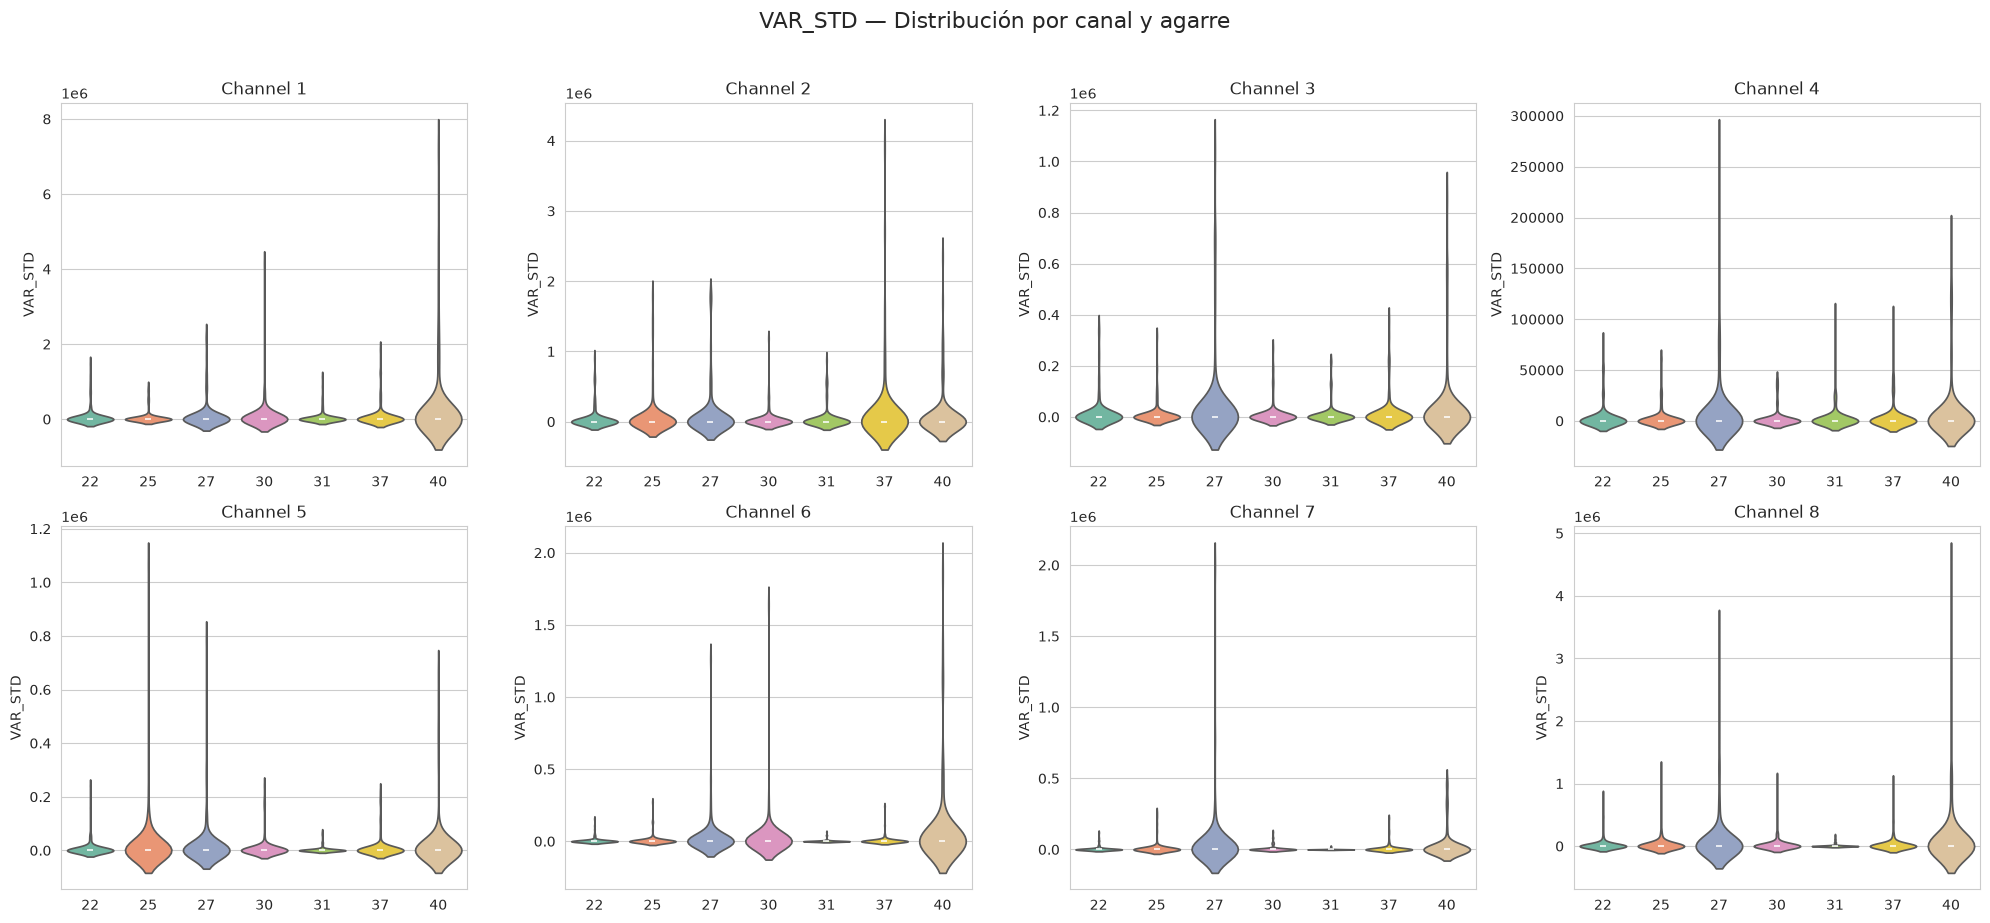

In [7]:
feat = 'VAR_STD'
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{feat} — Distribución por canal y agarre', fontsize=16, y=1.02)
for idx, ch in enumerate(range(1, 9)):
    ax = axes[ch // 5, (ch - 1) % 4]
    sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/122339672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/122339672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/122339672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/1

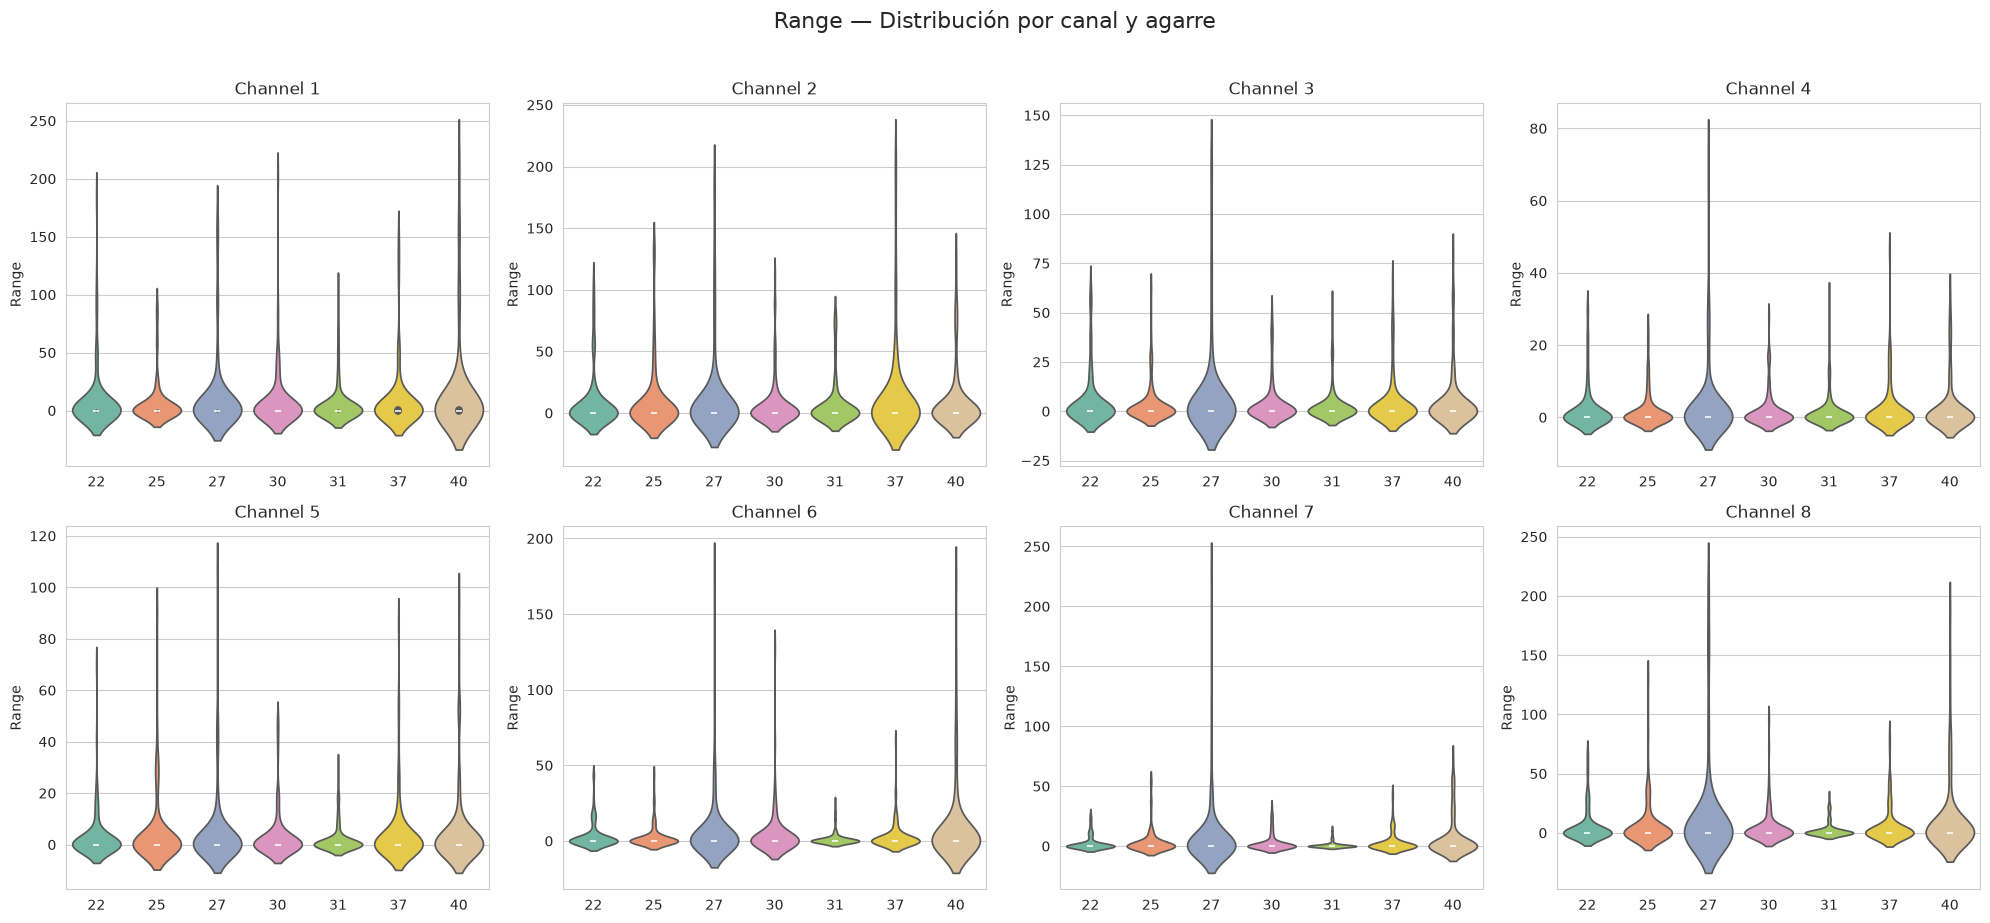

In [8]:
feat = 'Range'
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{feat} — Distribución por canal y agarre', fontsize=16, y=1.02)
for idx, ch in enumerate(range(1, 9)):
    ax = axes[ch // 5, (ch - 1) % 4]
    sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/3635012451.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/3635012451.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/3635012451.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_3541

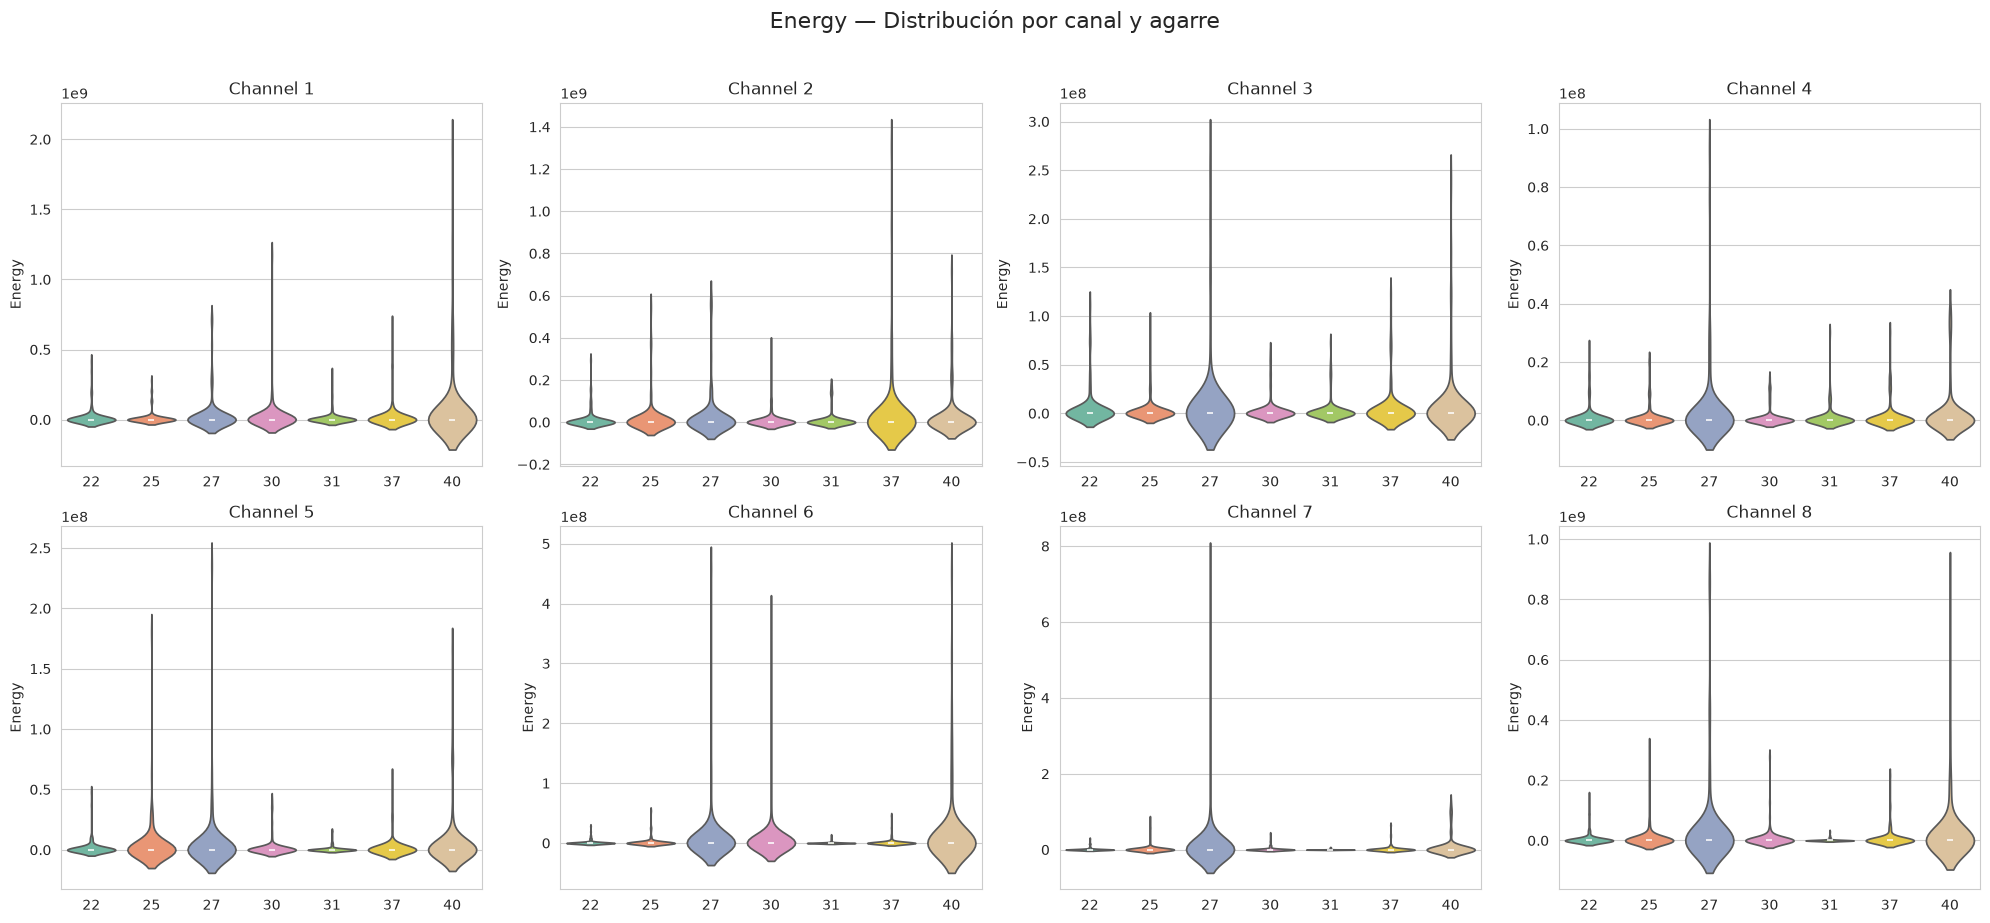

In [9]:
feat = 'Energy'
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{feat} — Distribución por canal y agarre', fontsize=16, y=1.02)
for idx, ch in enumerate(range(1, 9)):
    ax = axes[ch // 5, (ch - 1) % 4]
    sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/81055011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')


/tmp/ipykernel_35417/81055011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/81055011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/81055011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/8105

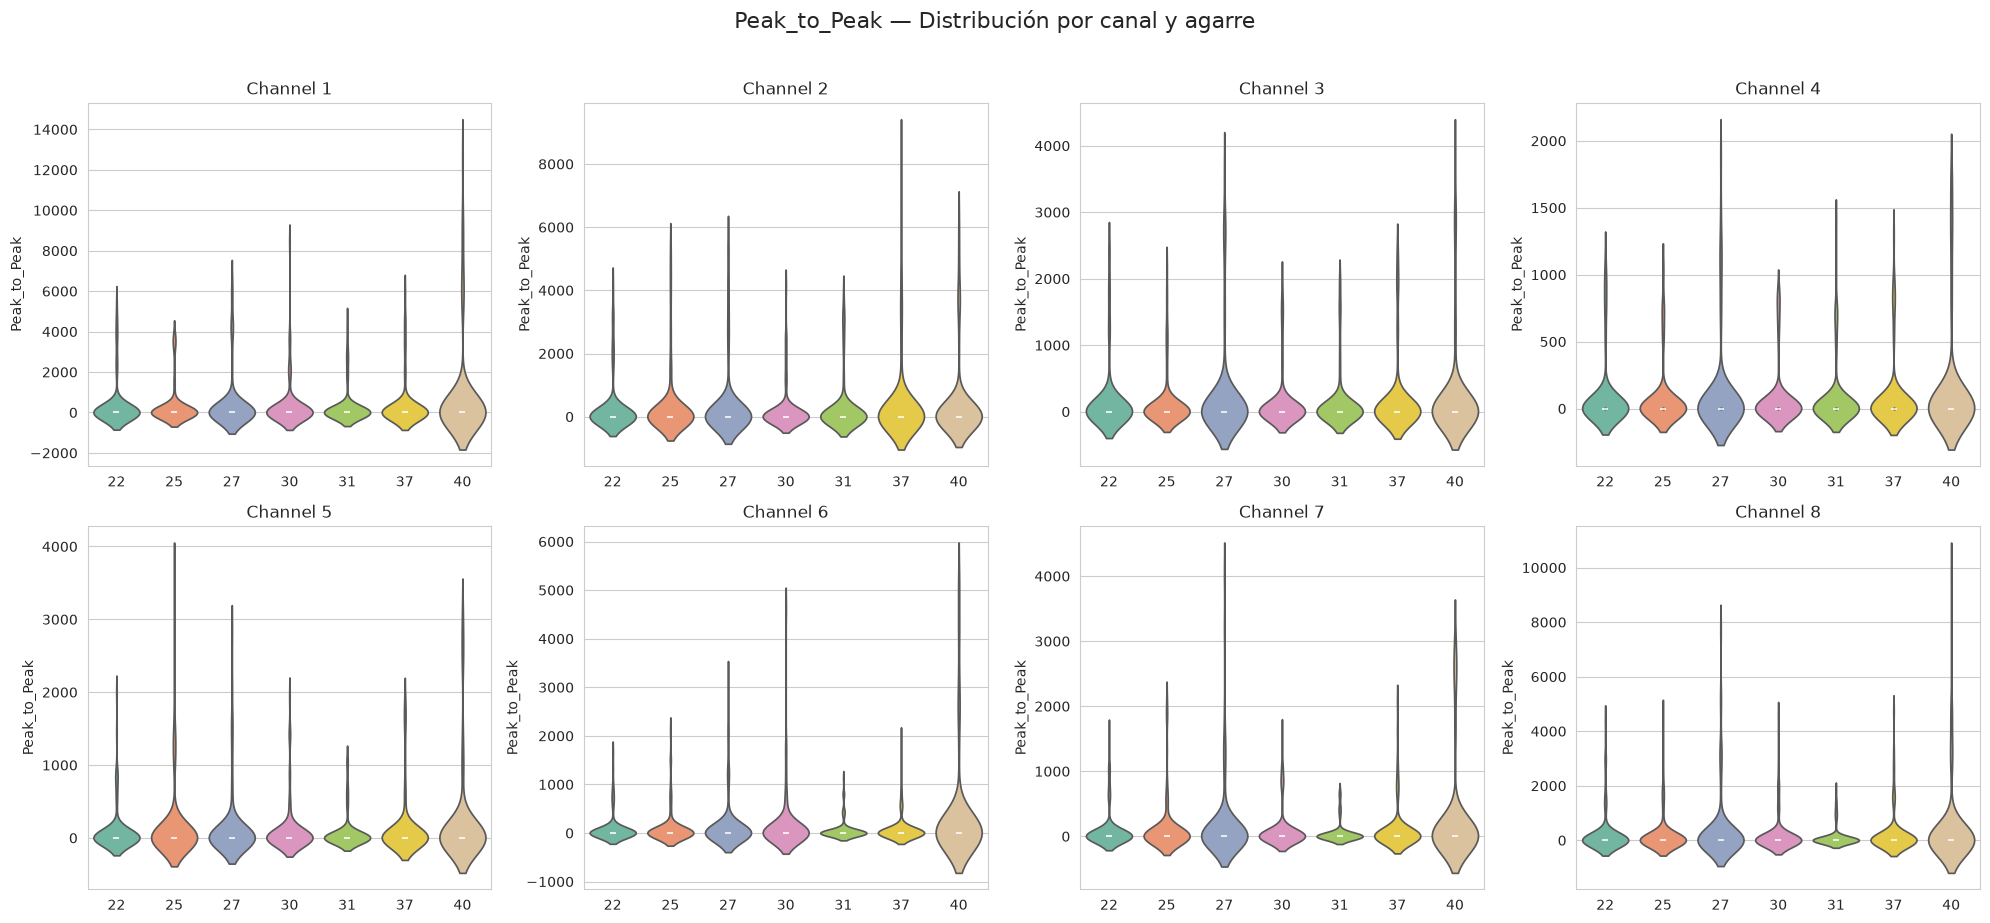

In [10]:
feat = 'Peak_to_Peak'
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{feat} — Distribución por canal y agarre', fontsize=16, y=1.02)
for idx, ch in enumerate(range(1, 9)):
    ax = axes[ch // 5, (ch - 1) % 4]
    sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/1670377708.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/1670377708.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/1670377708.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_3541

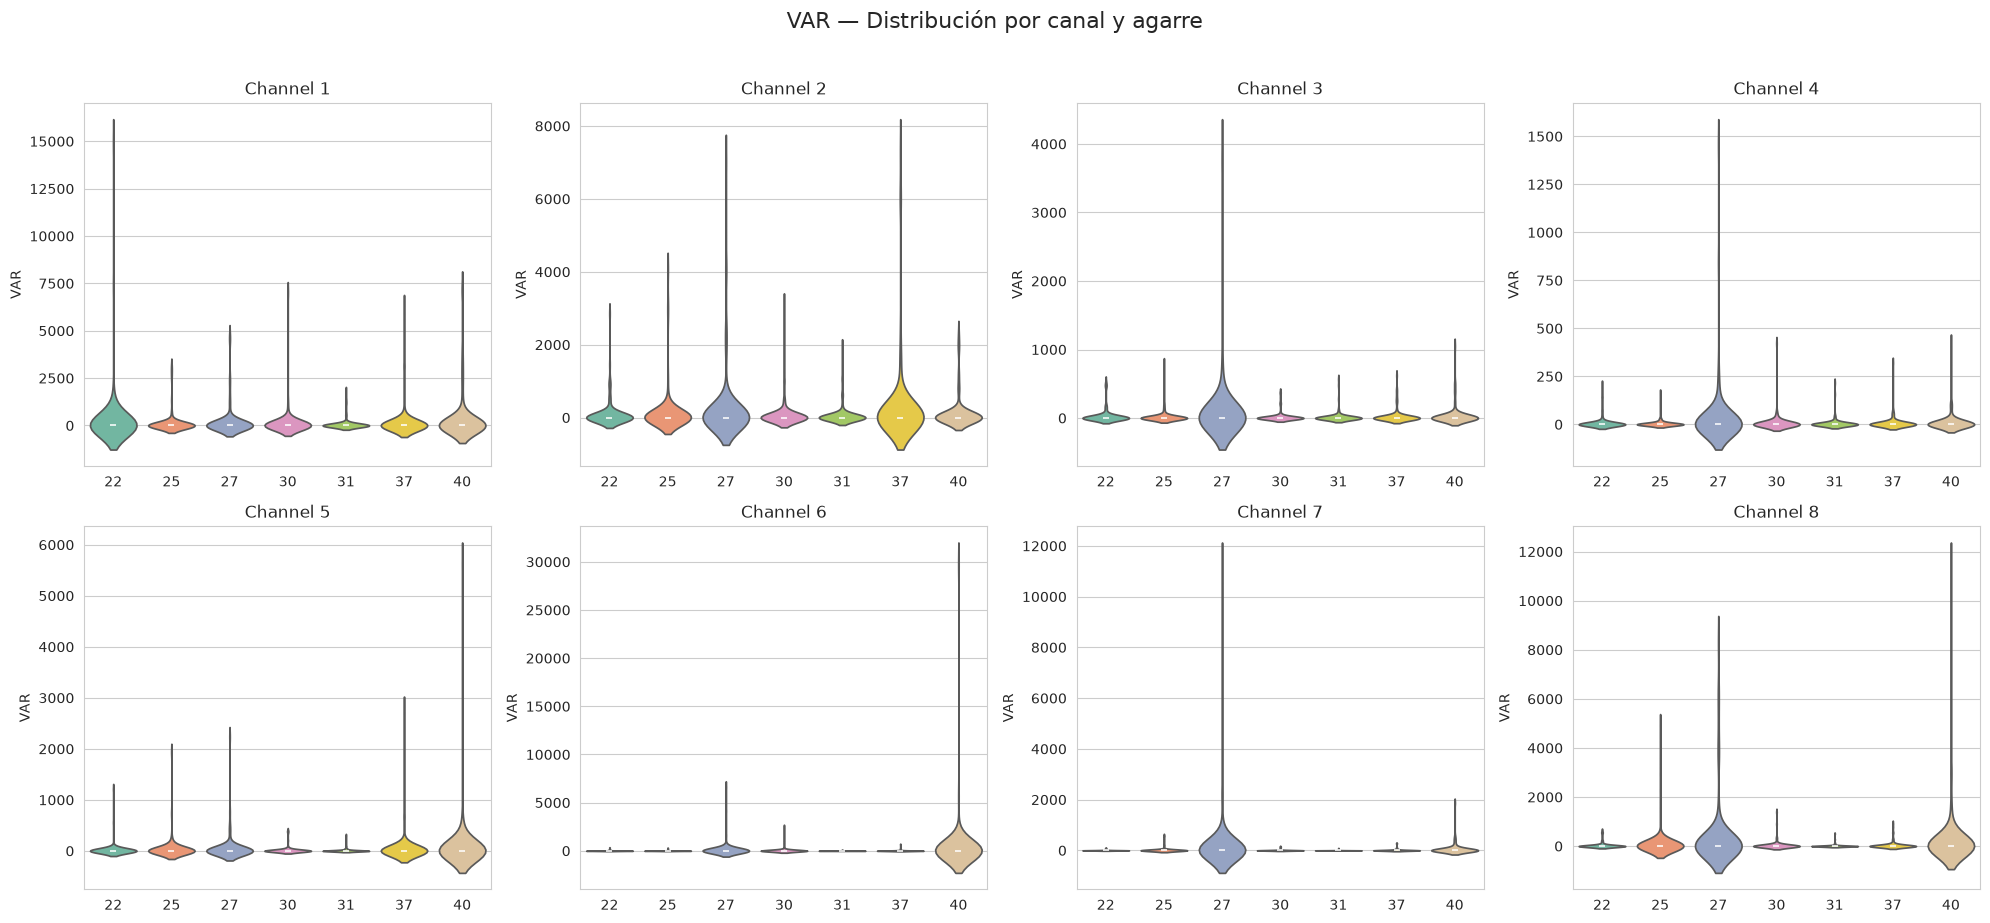

In [11]:
feat = 'VAR'
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{feat} — Distribución por canal y agarre', fontsize=16, y=1.02)
for idx, ch in enumerate(range(1, 9)):
    ax = axes[ch // 5, (ch - 1) % 4]
    sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/2093885738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/2093885738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/2093885738.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_3541

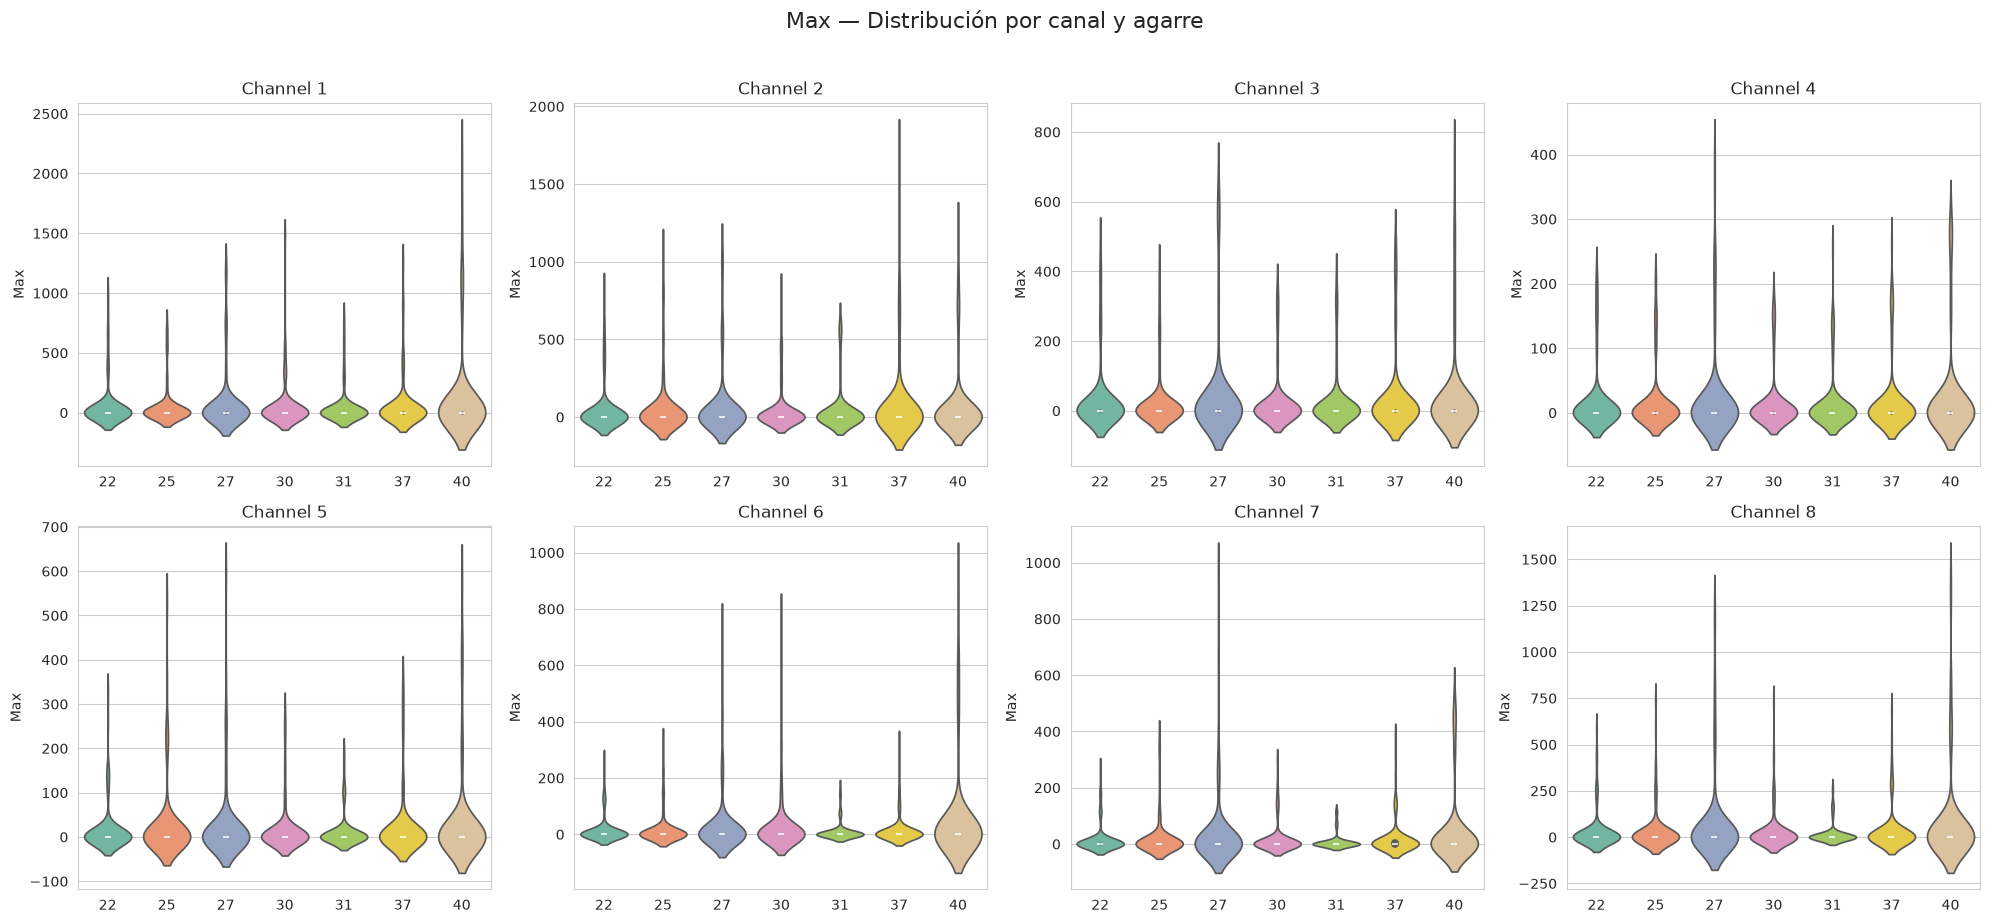

In [12]:
feat = 'Max'
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{feat} — Distribución por canal y agarre', fontsize=16, y=1.02)
for idx, ch in enumerate(range(1, 9)):
    ax = axes[ch // 5, (ch - 1) % 4]
    sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/2856595867.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/2856595867.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/2856595867.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_3541

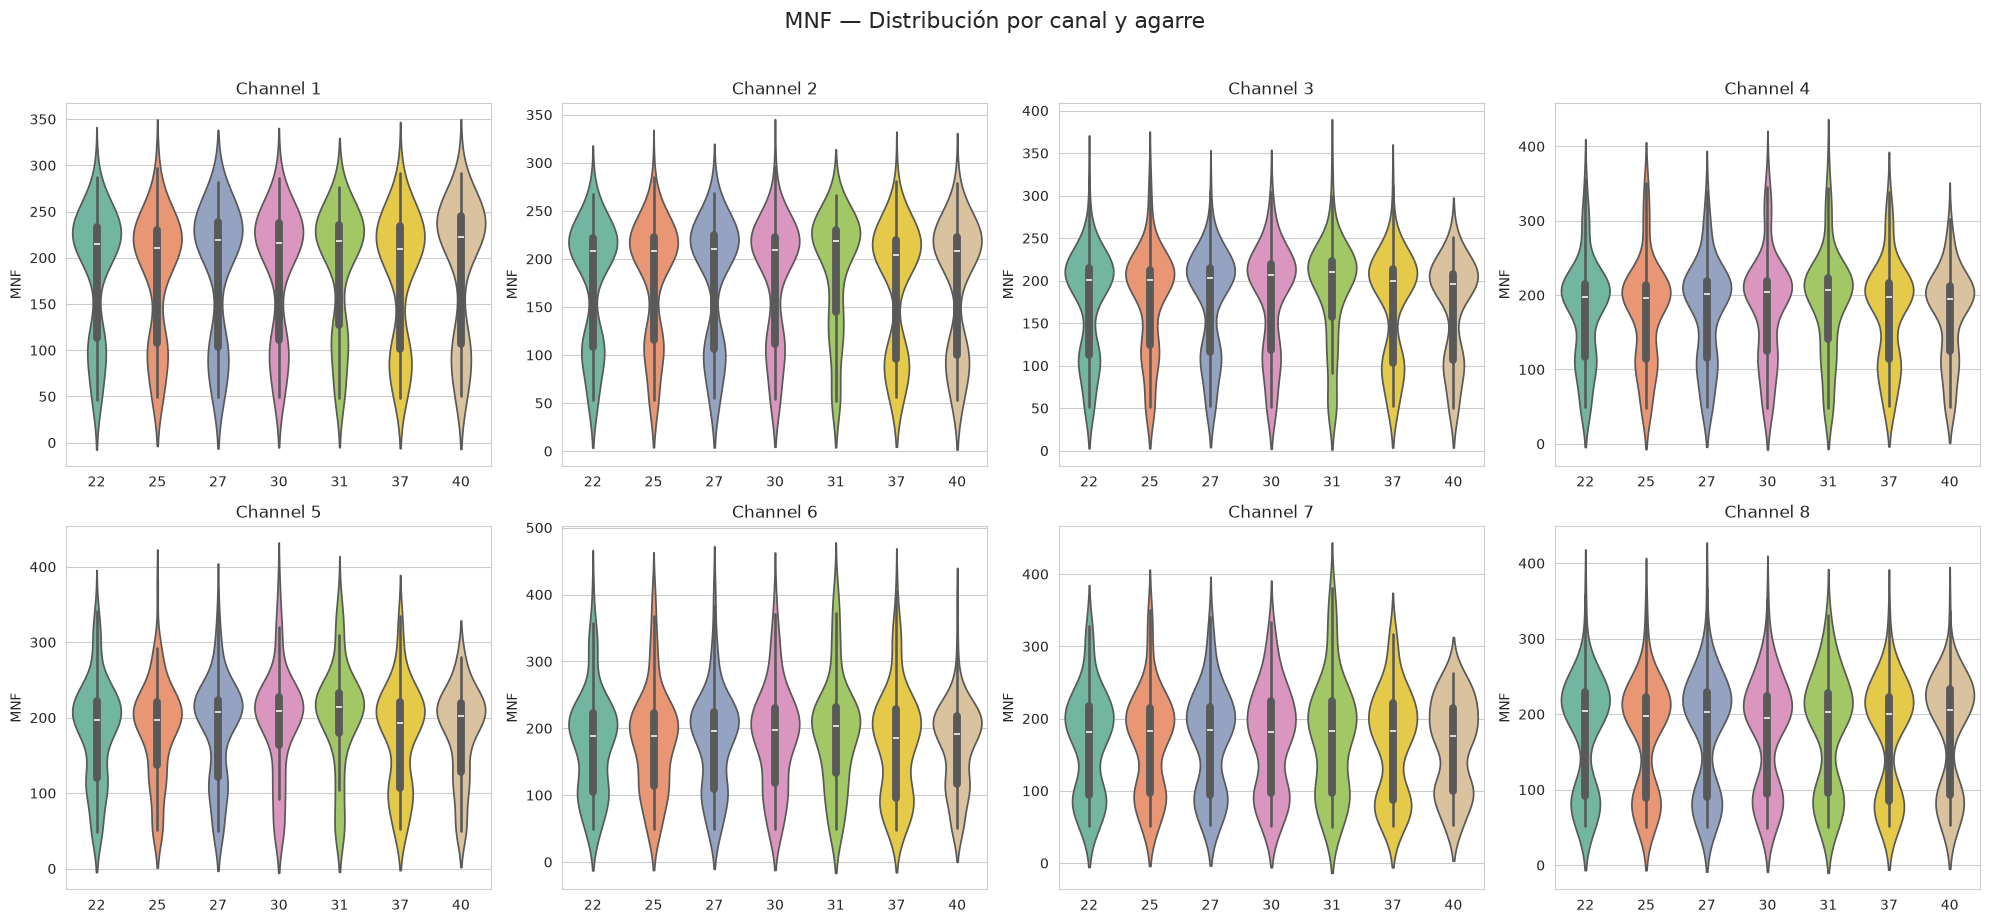

In [13]:
feat = 'MNF'
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{feat} — Distribución por canal y agarre', fontsize=16, y=1.02)
for idx, ch in enumerate(range(1, 9)):
    ax = axes[ch // 5, (ch - 1) % 4]
    sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/2362457104.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/2362457104.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/2362457104.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_3541

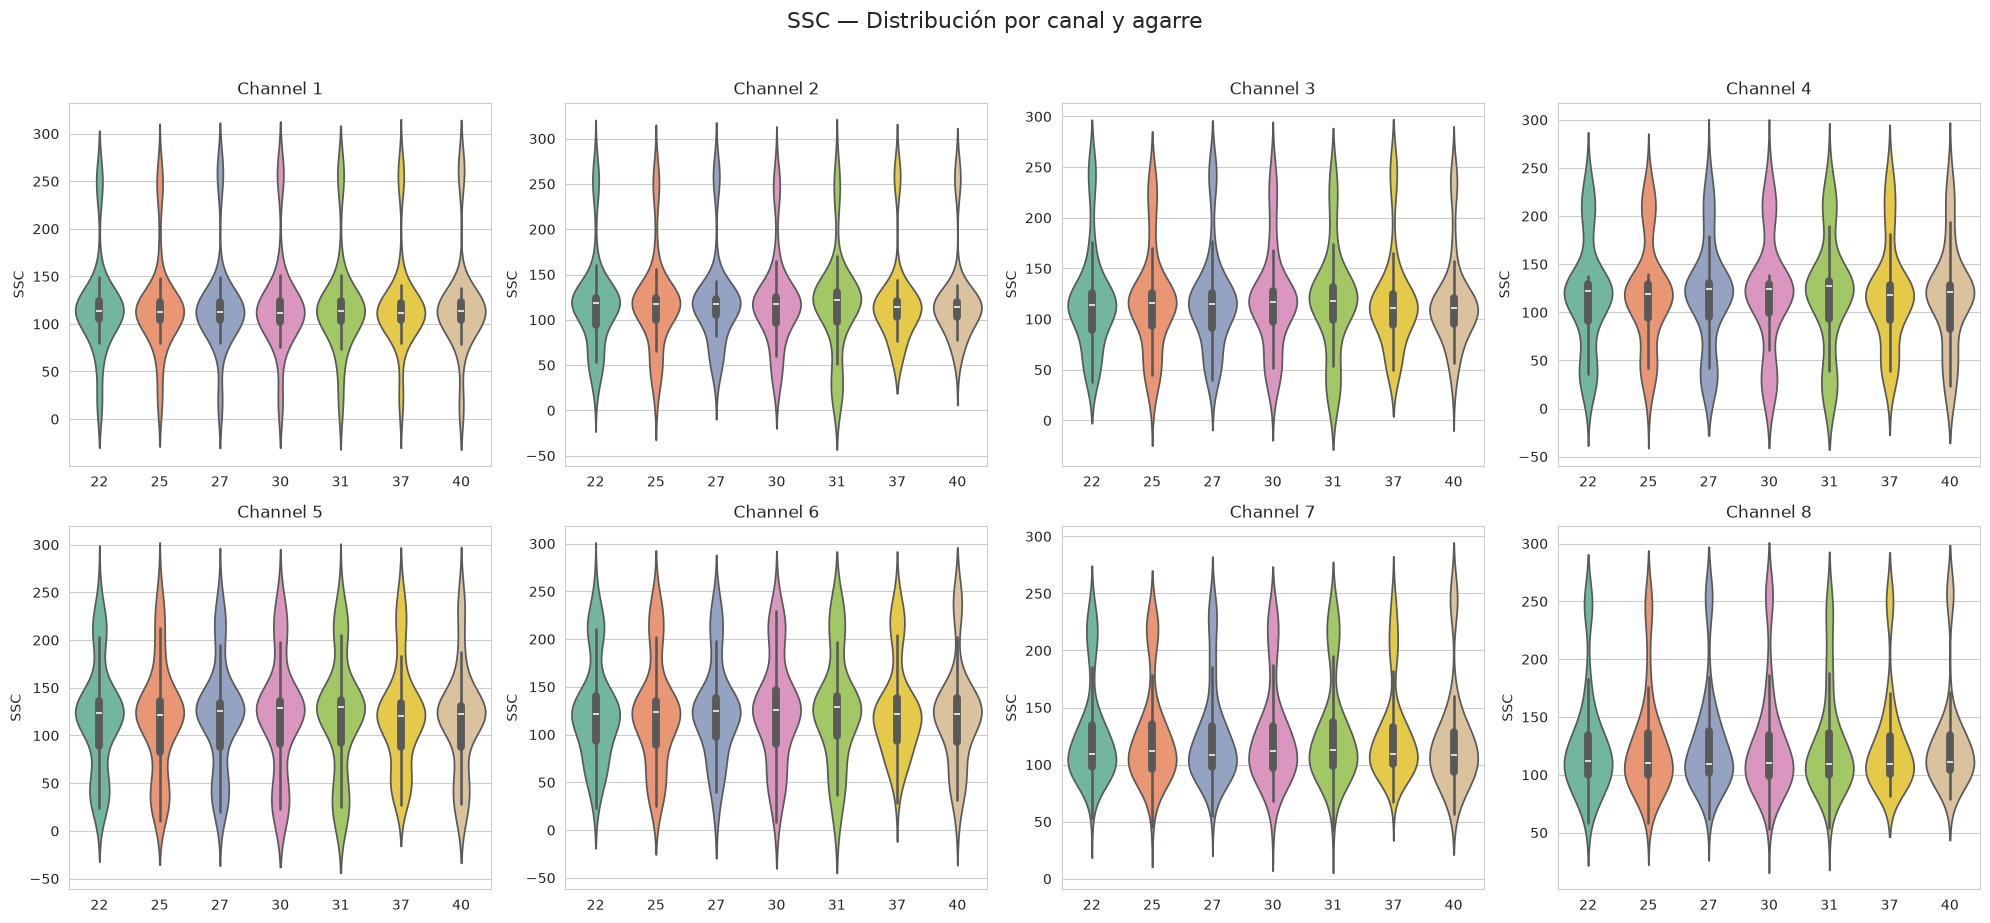

In [14]:
feat = 'SSC'
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{feat} — Distribución por canal y agarre', fontsize=16, y=1.02)
for idx, ch in enumerate(range(1, 9)):
    ax = axes[ch // 5, (ch - 1) % 4]
    sns.violinplot(data=df_avg, x='stimulus', y=f'Channel {ch}_{feat}', ax=ax, palette='Set2', inner='box')
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` 

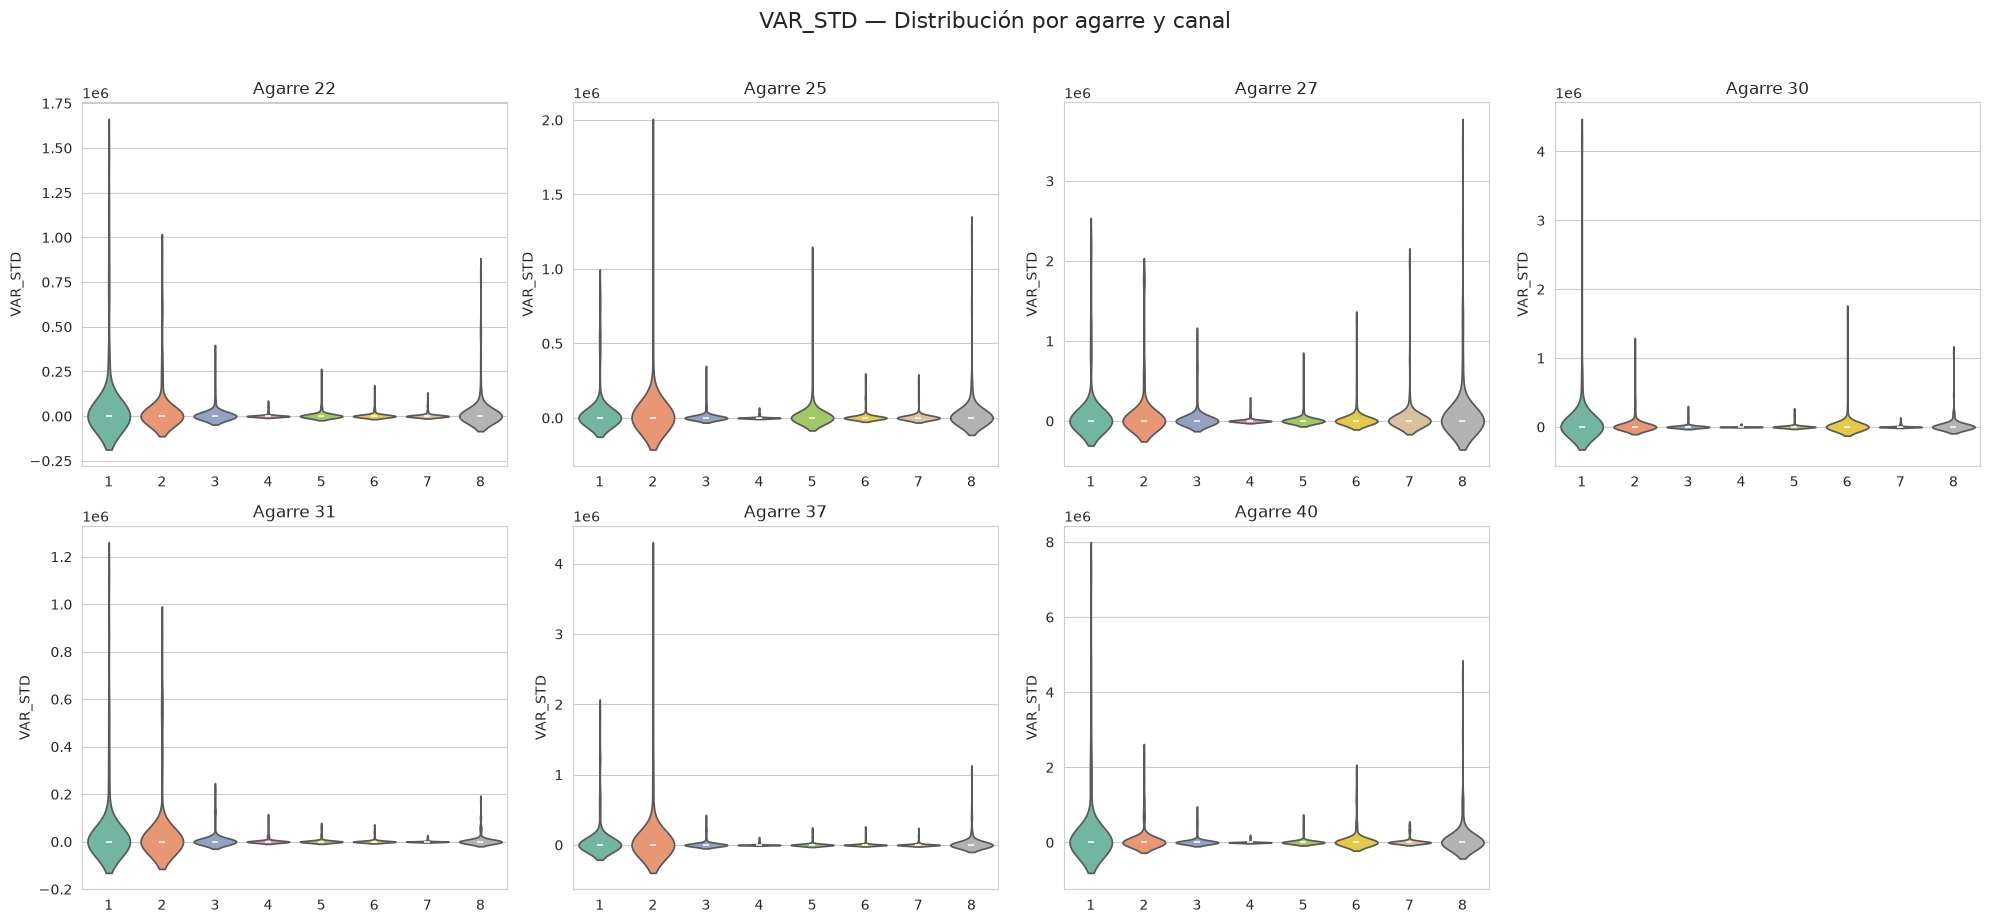

/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` 

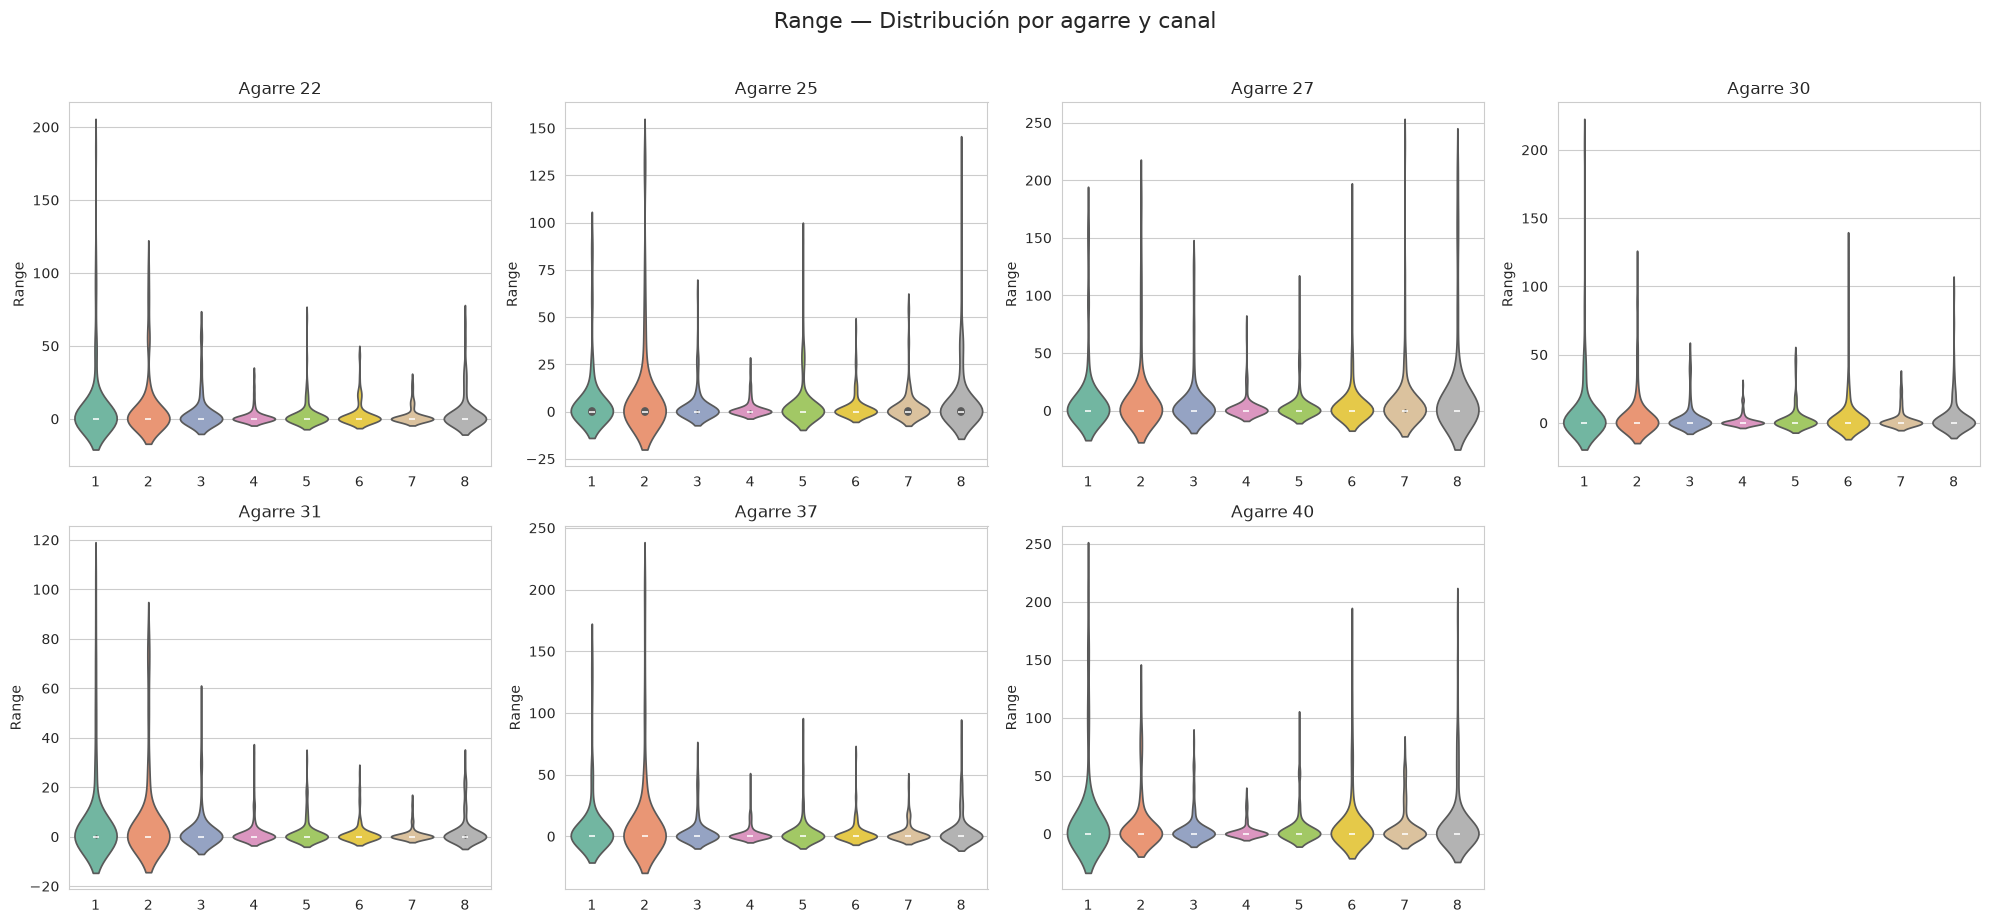

/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` 

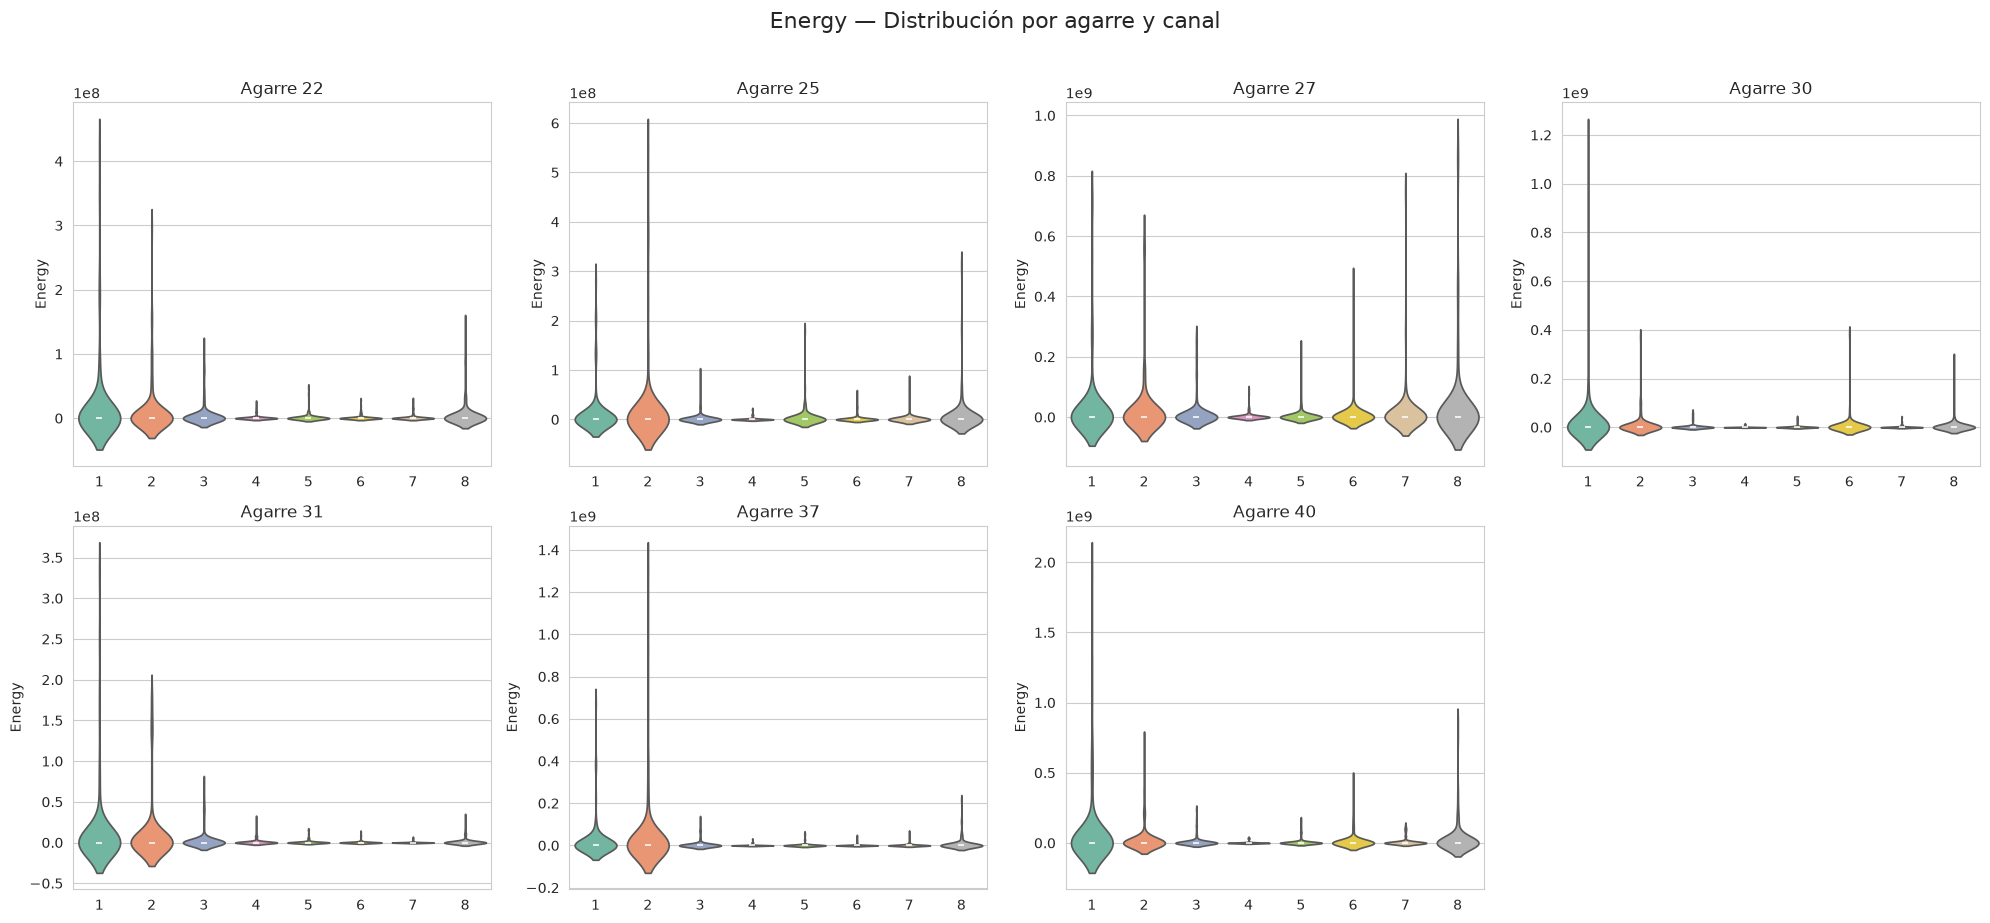

/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` 

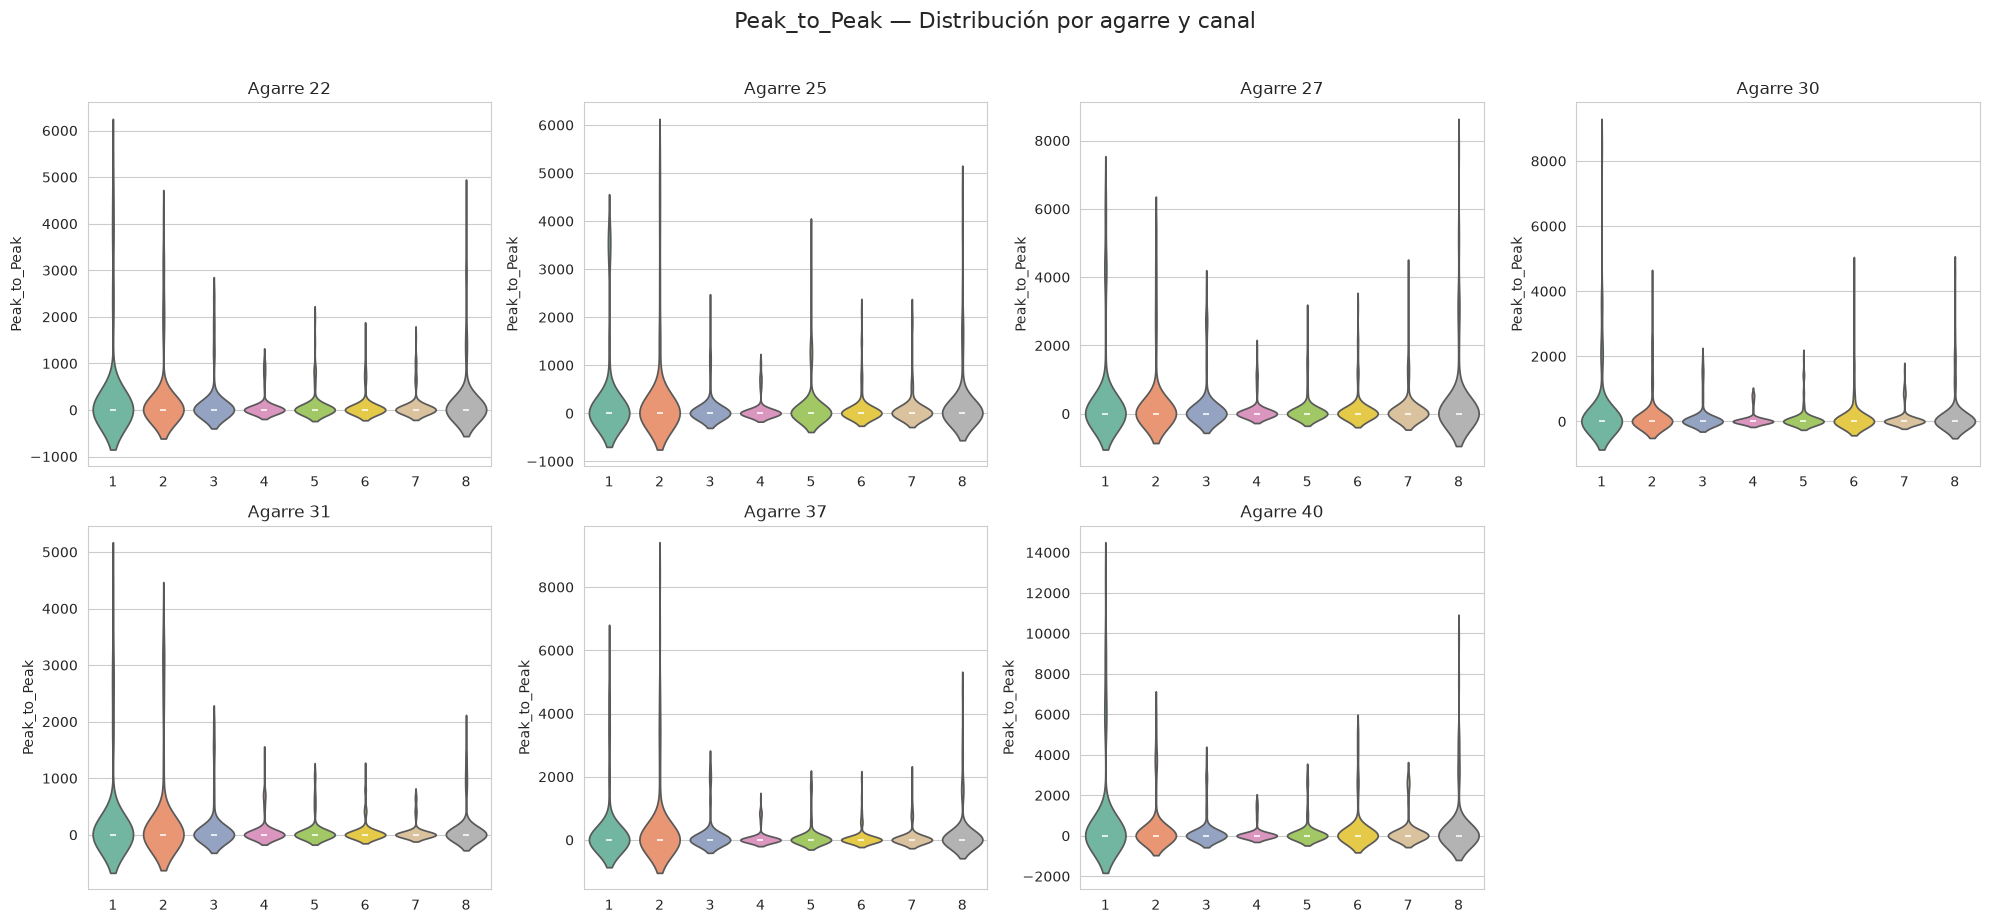

/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` 

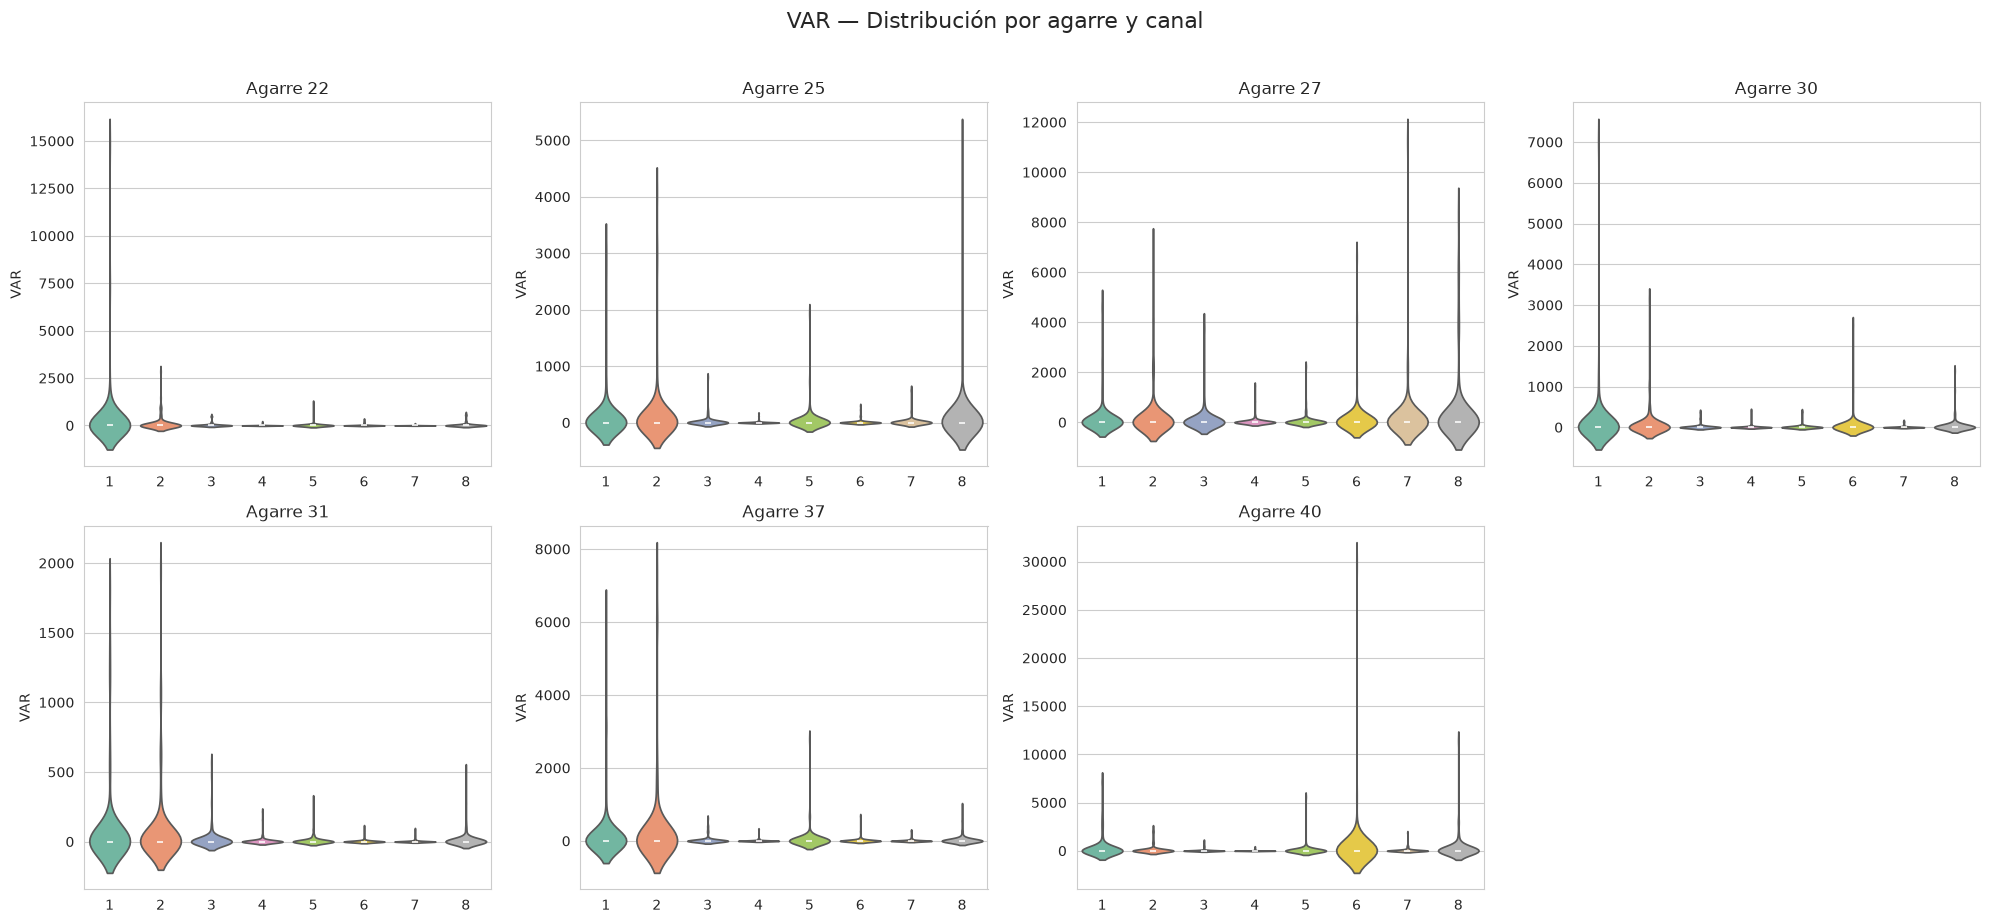

/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` 

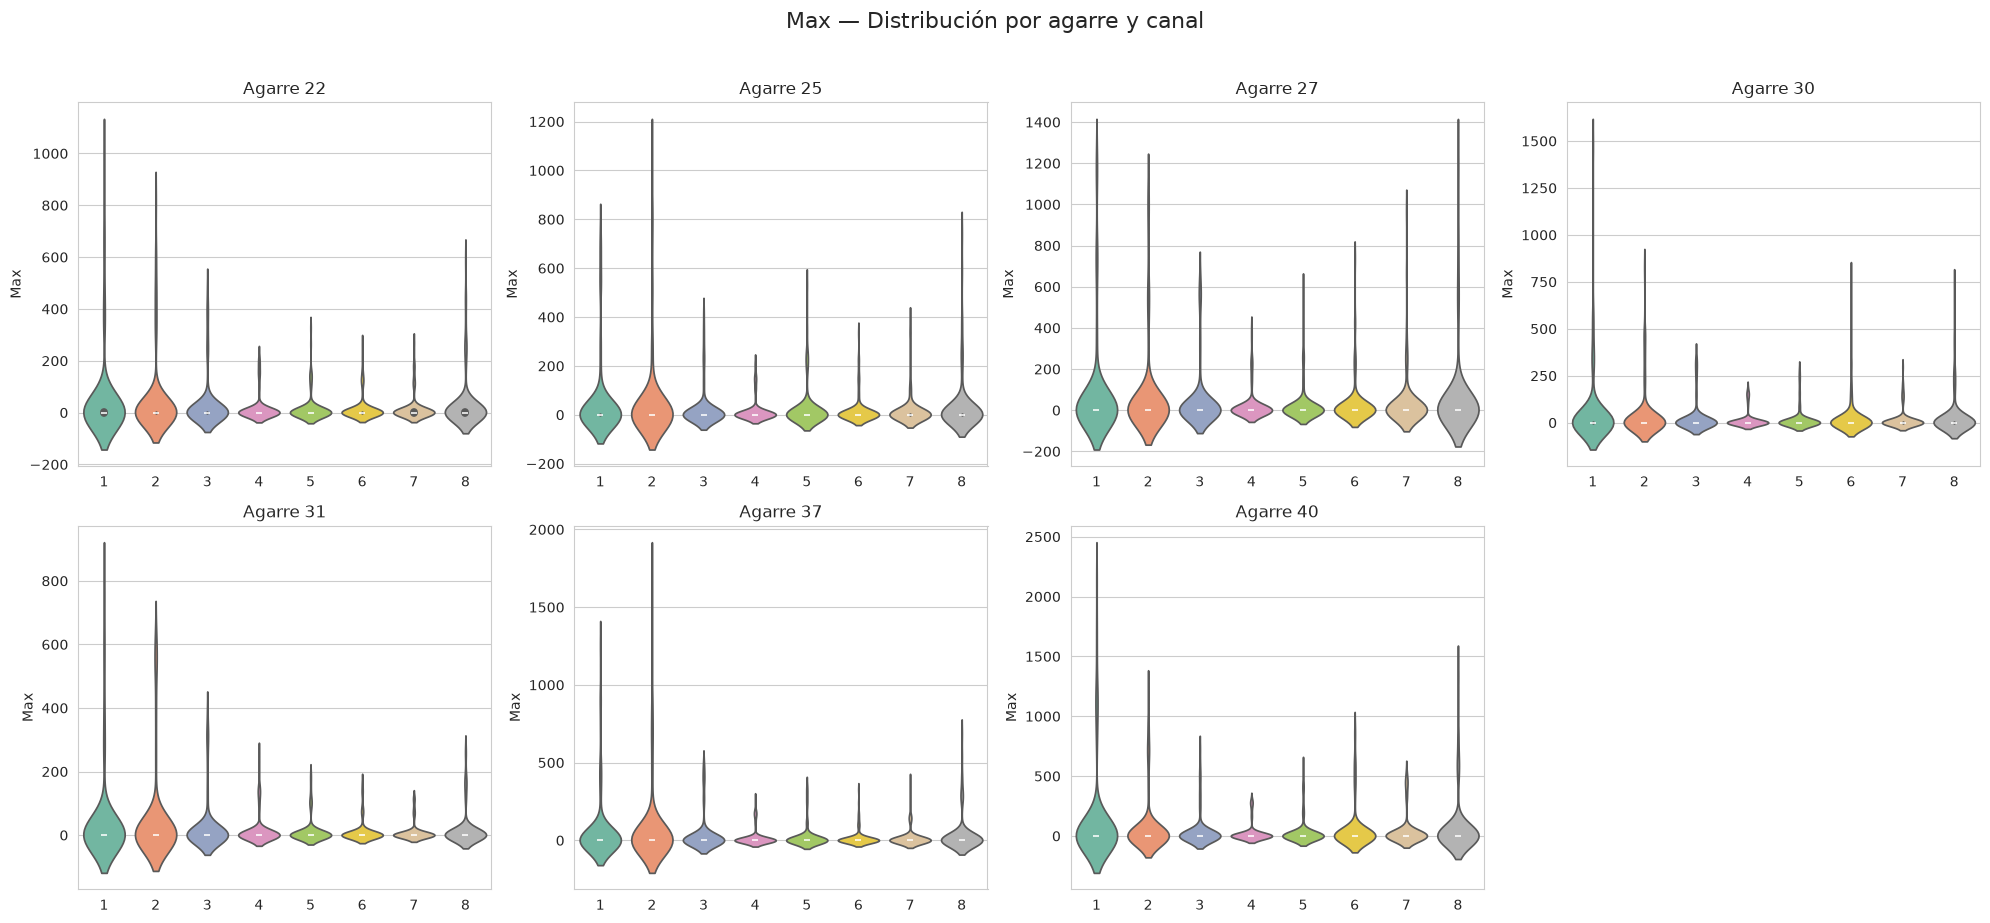

/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` 

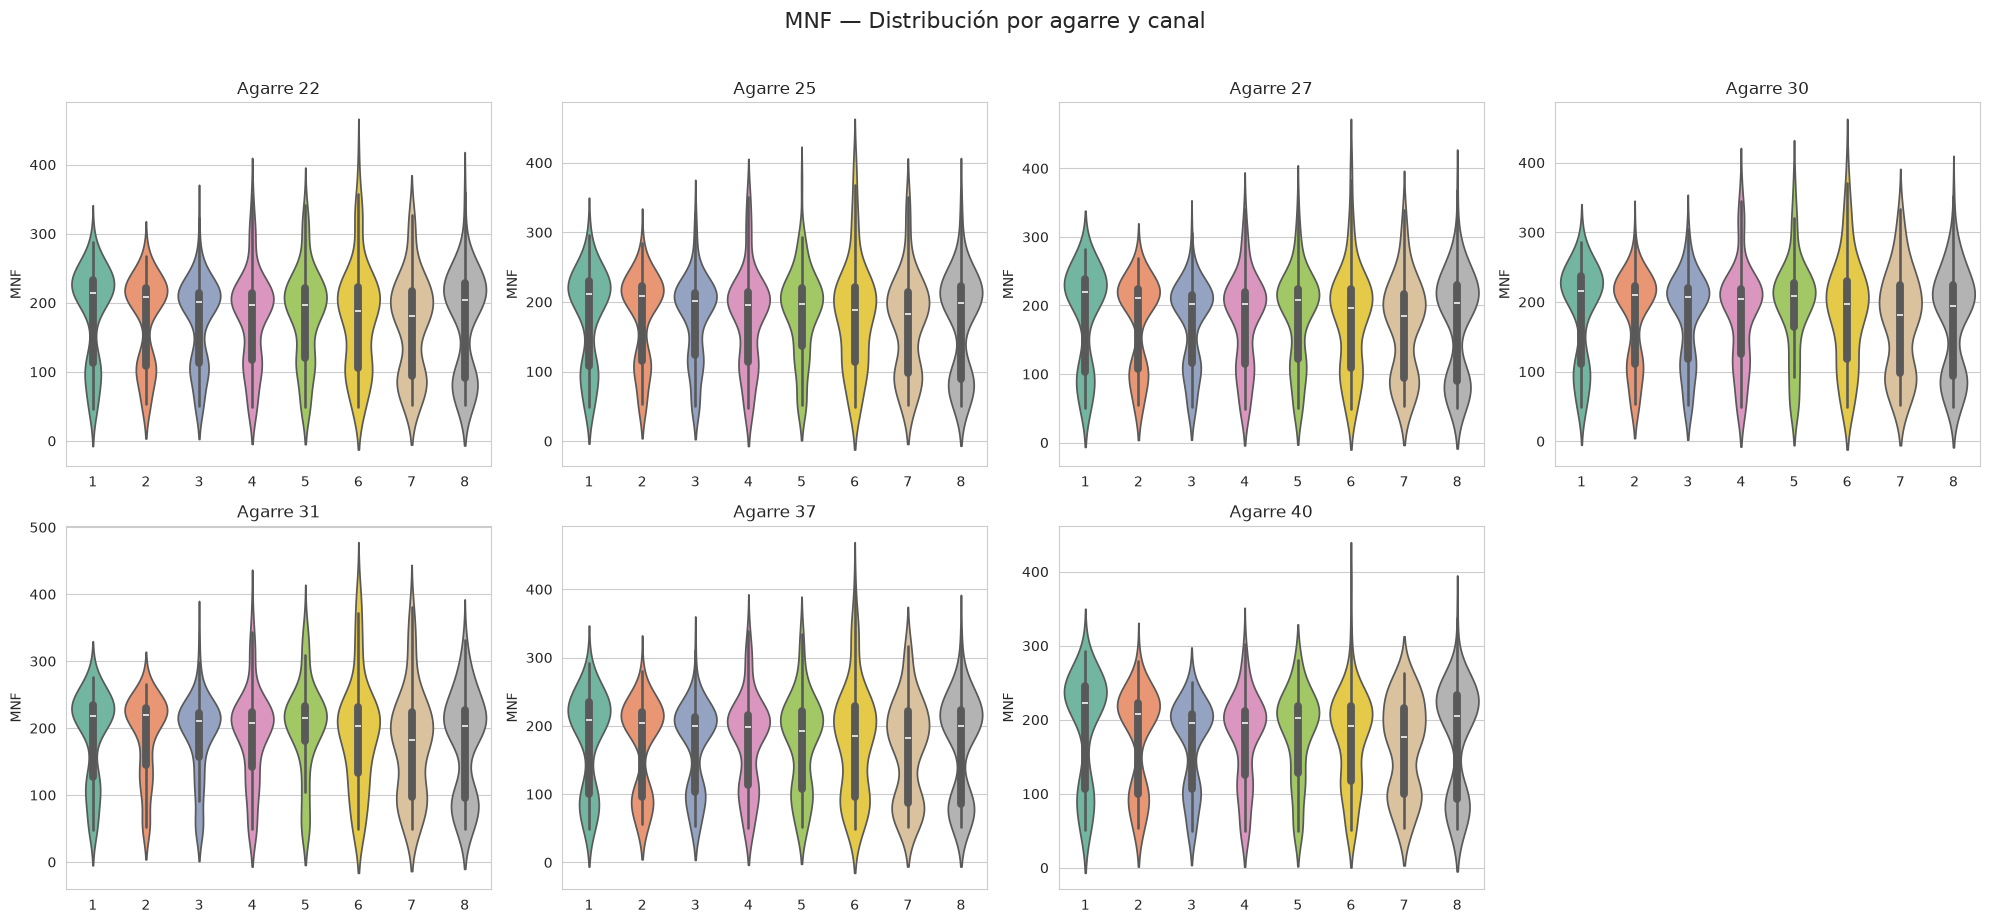

/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
/tmp/ipykernel_35417/232300110.py:17: FutureWarning: 

Passing `palette` 

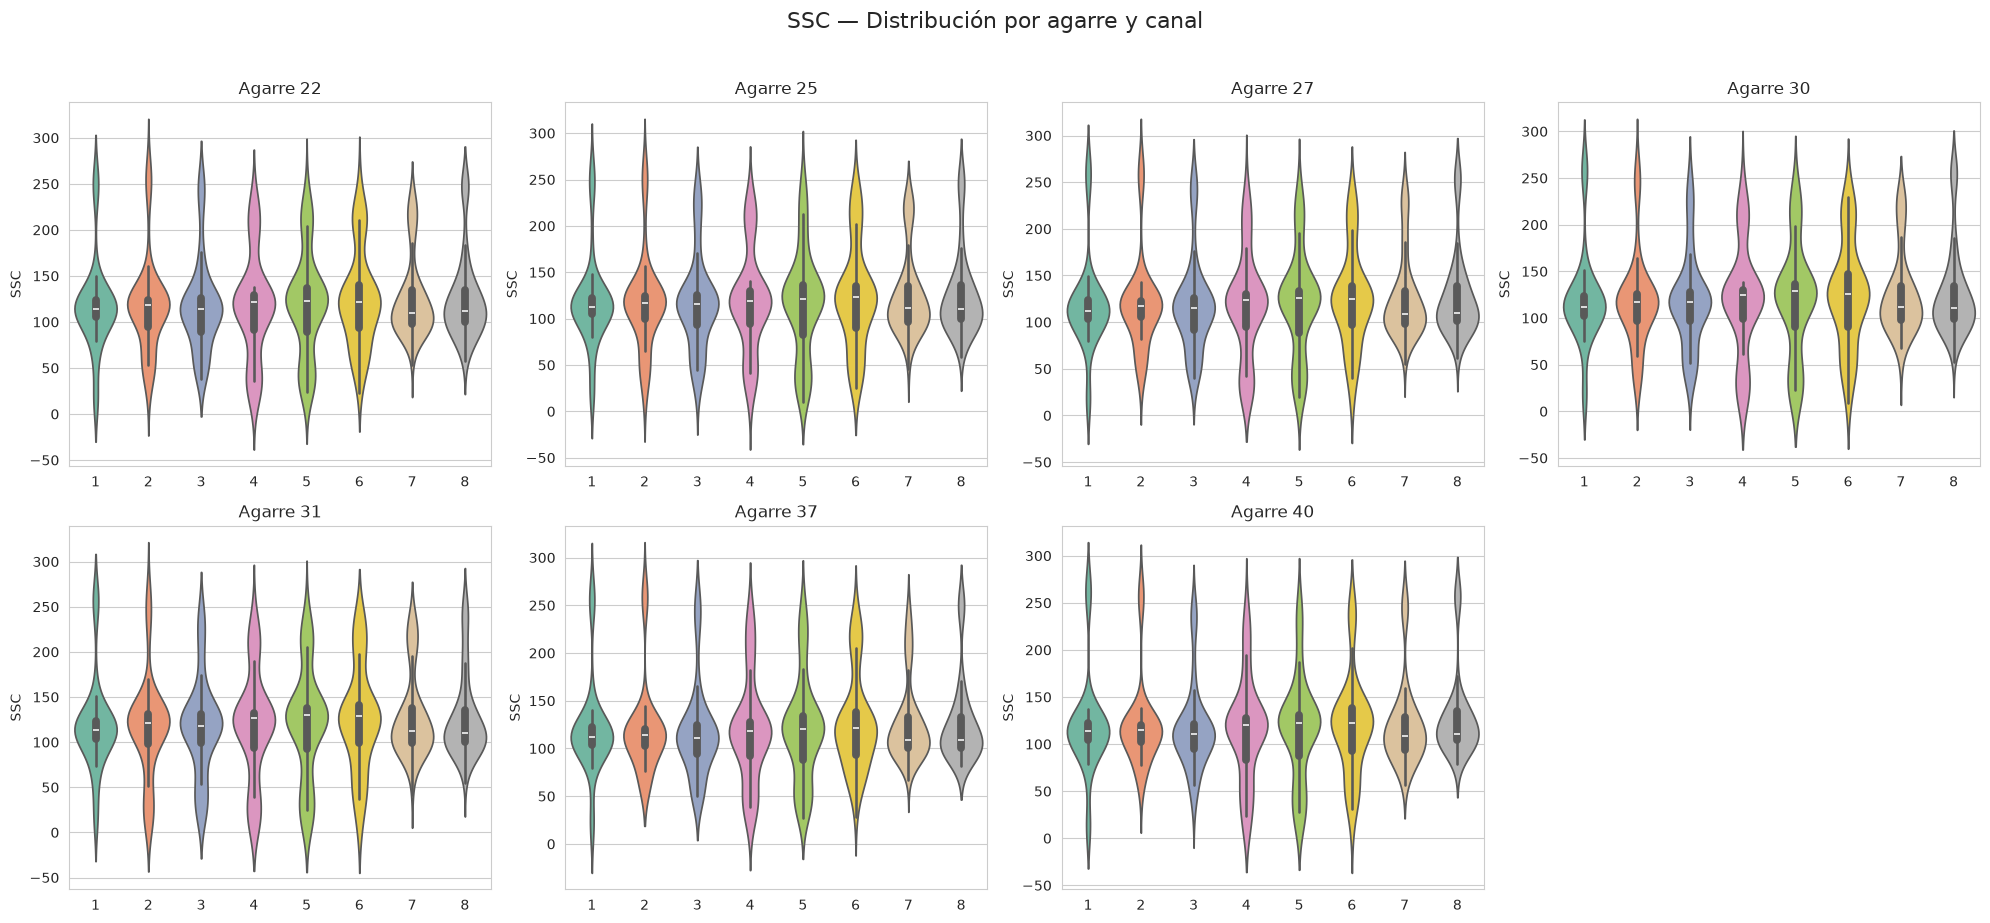

In [15]:
def plot_violin_by_grasp(feat, stimuli, ncols=4):
    """Violin plot de `feat` por canal, un subplot por cada agarre."""
    n = len(stimuli)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    fig.suptitle(f'{feat} — Distribución por agarre y canal', fontsize=16, y=1.02)

    for idx, stim in enumerate(stimuli):
        ax = axes[idx]
        df_stim = df_avg[df_avg['stimulus'] == stim]

        cols = [f'Channel {ch}_{feat}' for ch in range(1, 9)]
        df_long = df_stim[cols].melt(var_name='Channel', value_name=feat)
        df_long['Channel'] = df_long['Channel'].str.extract(r'Channel (\d+)')

        sns.violinplot(data=df_long, x='Channel', y=feat, ax=ax, palette='Set2', inner='box')
        ax.set_title(f'Agarre {stim}')
        ax.set_xlabel('')
        ax.set_ylabel(feat)

    # Ocultar subplots sobrantes si stimuli no llena la grilla
    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

selected_stimuli = sorted(df_avg['stimulus'].unique())

for feat in features:
    plot_violin_by_grasp(feat, selected_stimuli)

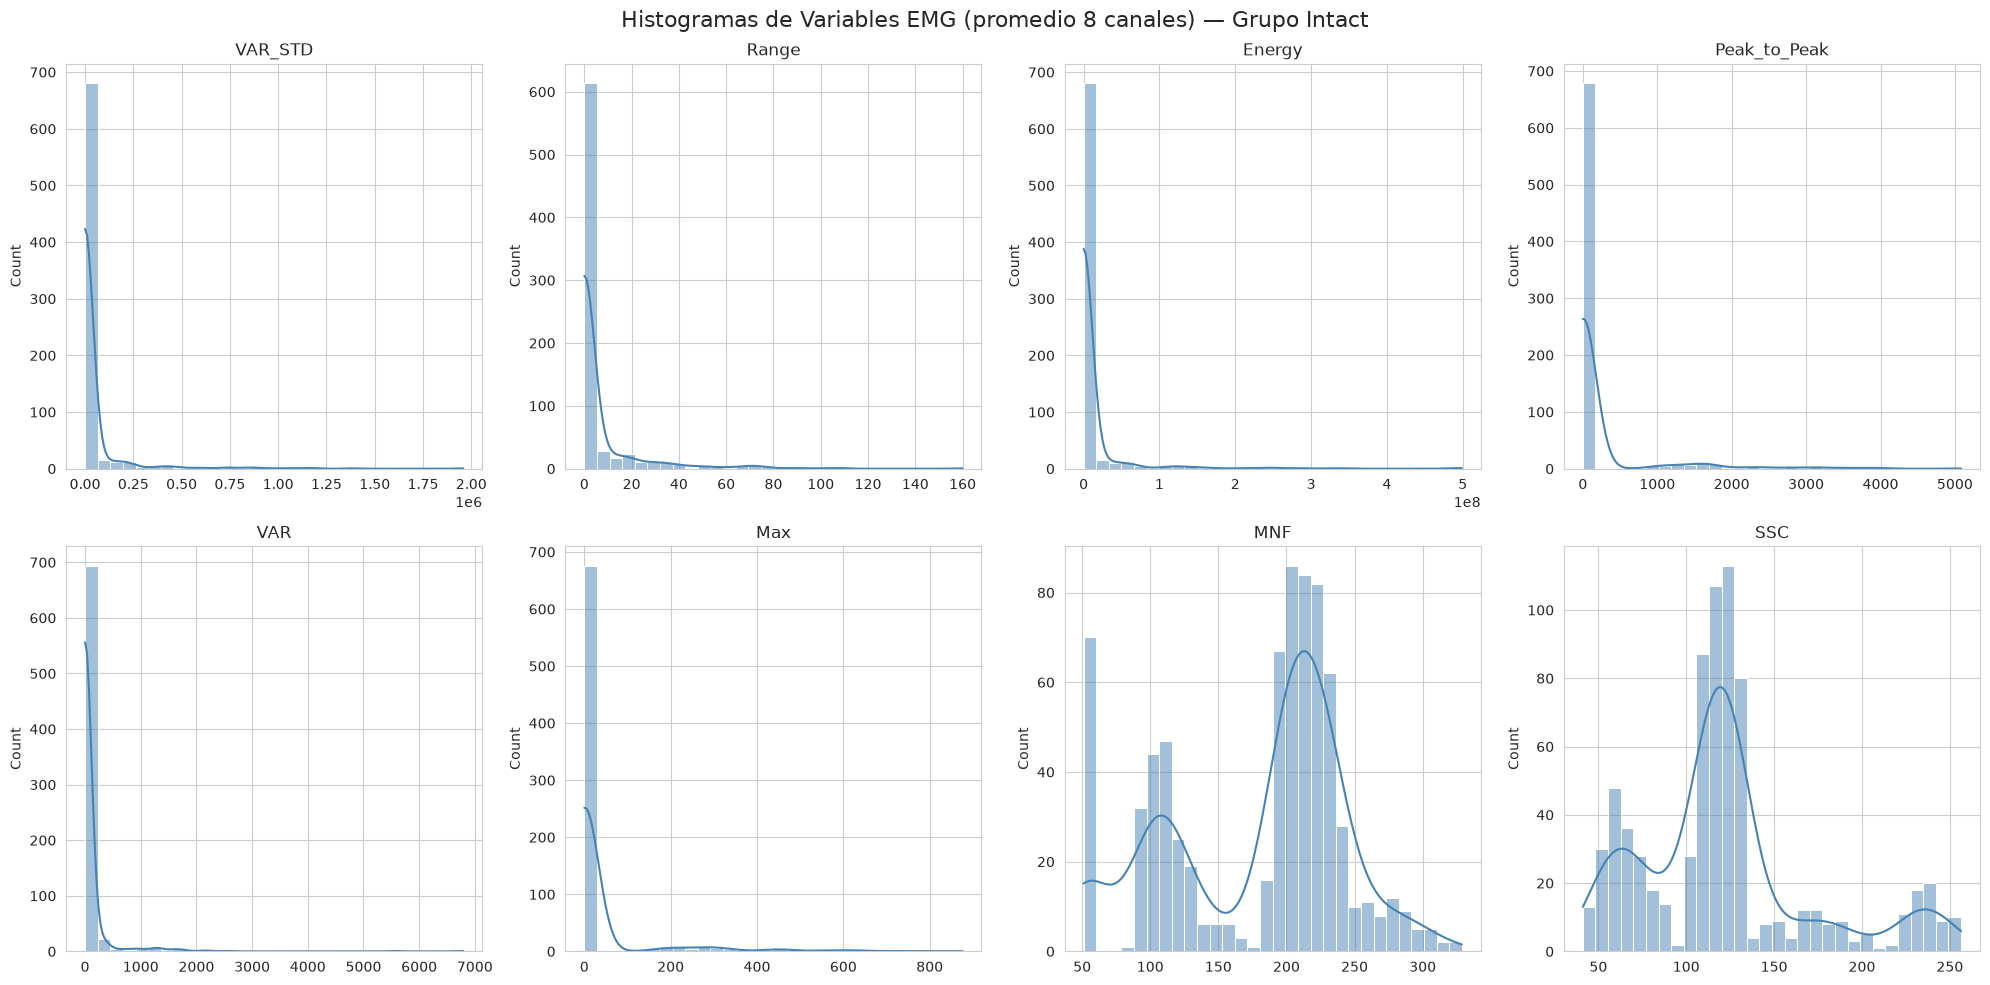

In [38]:
features = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Histogramas de Variables EMG (promedio 8 canales) — Grupo Intact', fontsize=16)

for i, feat in enumerate(features):
    ax = axes[i // 4][i % 4]
    # Promedio de los 8 canales para esta feature
    mean_vals = df_avg[[f'Channel {ch}_{feat}' for ch in range(1, 9)]].mean(axis=1)
    sns.histplot(mean_vals, kde=True, ax=ax, bins=30, color='steelblue')
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 3. Heatmap de promedios por agarre

Promedio de cada feature por canal y tipo de agarre. Los valores más altos (rojo) indican mayor actividad en ese canal para ese agarre.

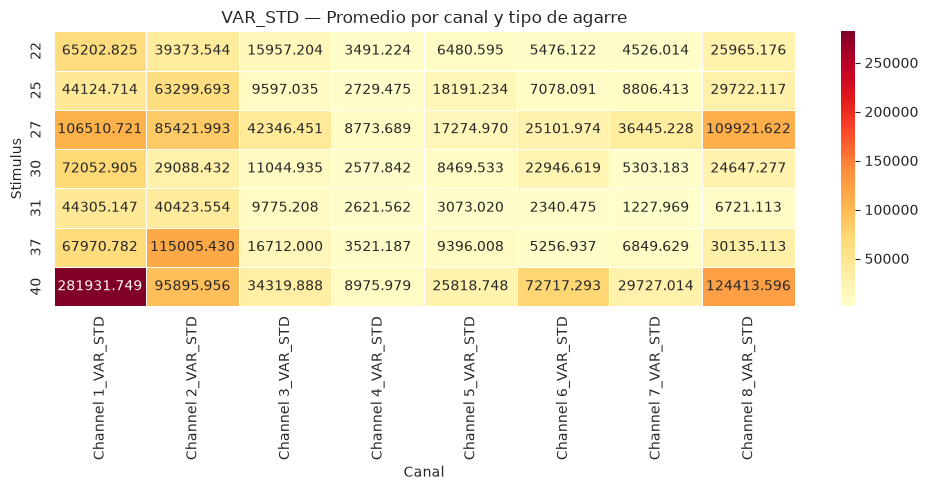

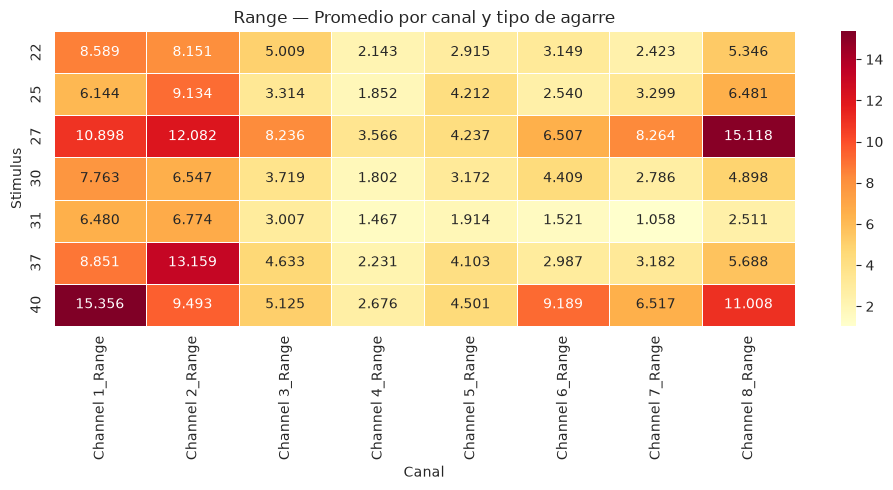

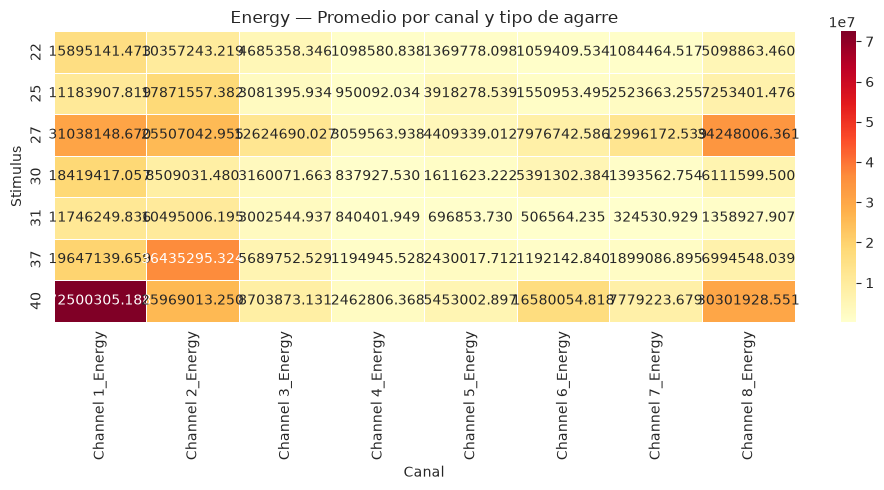

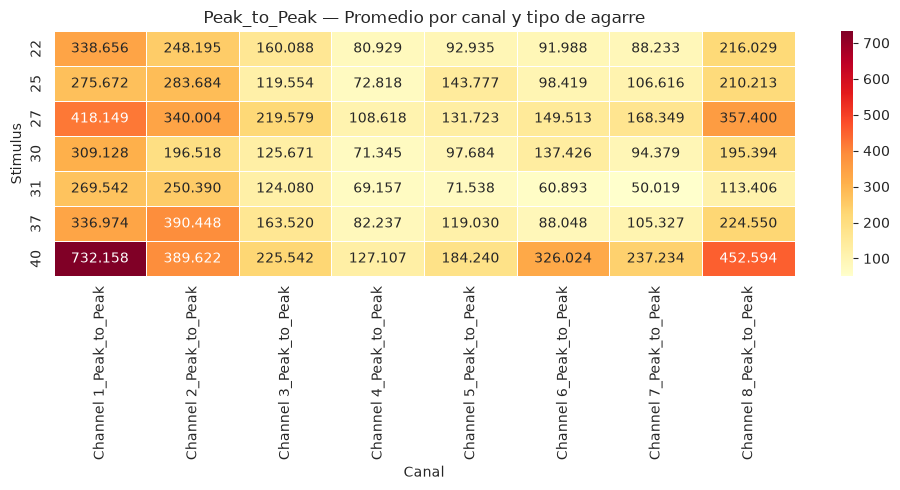

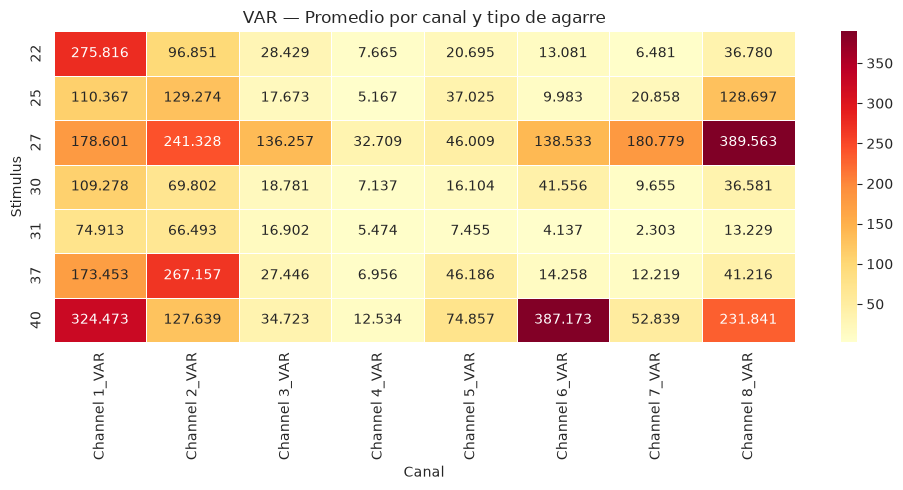

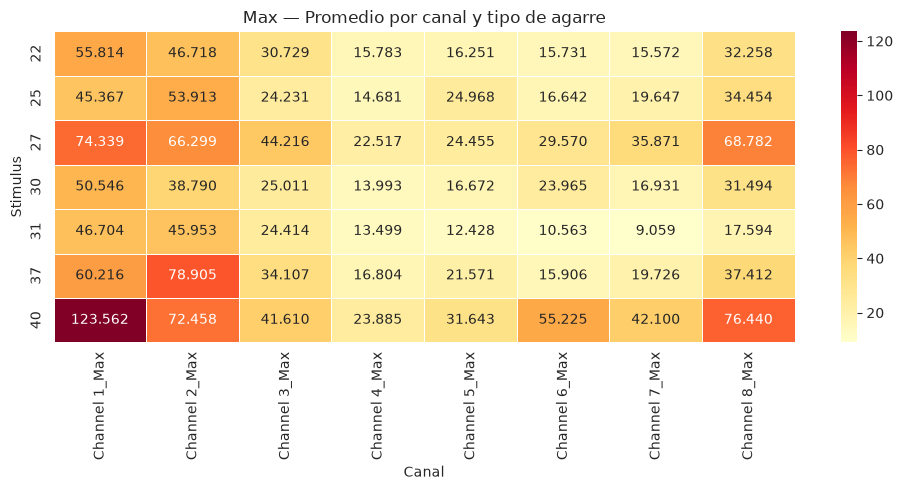

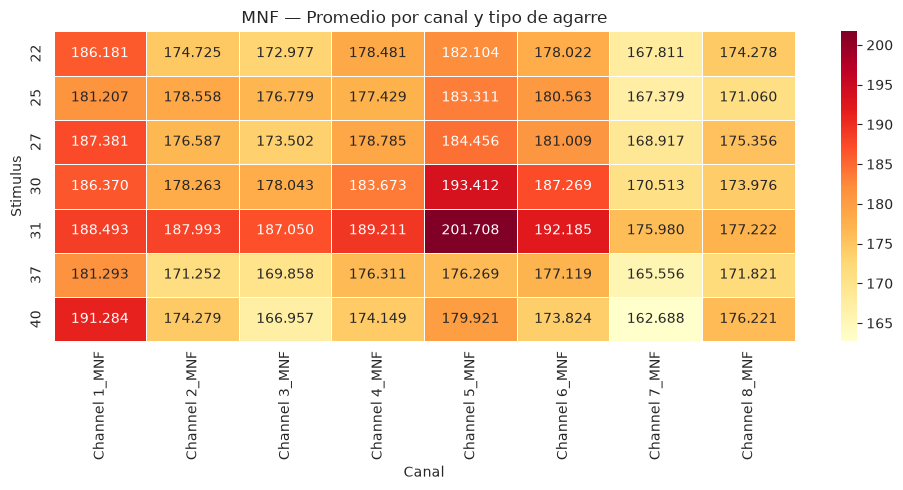

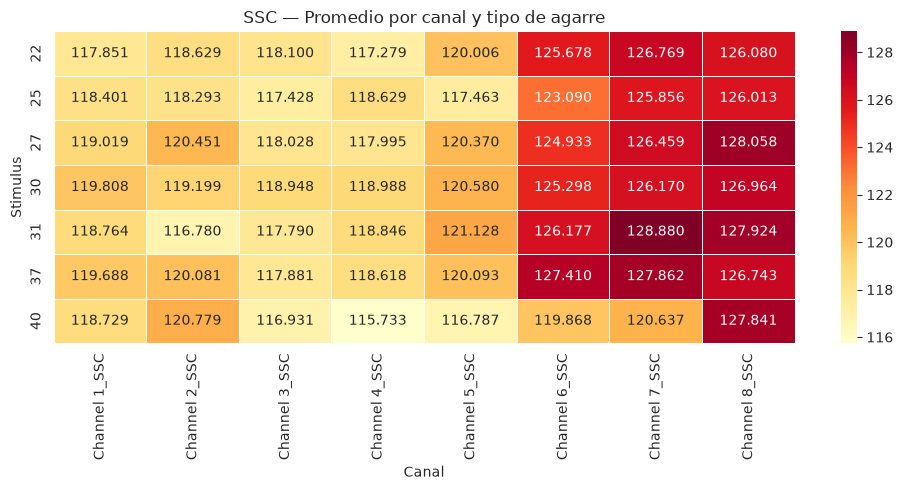

In [17]:
for feat in features:
    ch_cols = [f'Channel {ch}_{feat}' for ch in range(1, 9)]
    pivot = df_avg.groupby('stimulus')[ch_cols].mean()
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
    plt.title(f'{feat} — Promedio por canal y tipo de agarre')
    plt.xlabel('Canal')
    plt.ylabel('Stimulus')
    plt.tight_layout()
    plt.show()


## 4. Tests estadísticos — Diferencias entre agarres
 Friedman: test no paramétrico para medidas repetidas (mismos sujetos en todos los estímulos)

In [18]:
from scipy.stats import friedmanchisquare


friedman_results = []
for feat in signal_cols:
    groups = []
    for stim in sorted(df_avg['stimulus'].unique()):
        vals = df_avg[df_avg['stimulus'] == stim][feat].values
        groups.append(vals)
    
    min_len = min(len(g) for g in groups)
    groups = [g[:min_len] for g in groups]
    
    if len(groups) >= 3:
        stat, p_value = friedmanchisquare(*groups)
        friedman_results.append({'Feature': feat, 'H-statistic': round(stat, 3), 'p-value': p_value})

friedman_df = pd.DataFrame(friedman_results).sort_values('p-value')
friedman_df['Significativo'] = friedman_df['p-value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)
friedman_df

,Feature,H-statistic,p-value,Significativo
61,Channel 8_Max,226.854,3.591196e-46,***
21,Channel 3_Max,221.083,6.114514e-45,***
5,Channel 1_Max,220.222,9.332516e-45,***
19,Channel 3_Peak_to_Peak,218.567,2.102401e-44,***
53,Channel 7_Max,217.570,3.430417e-44,***
...,...,...,...,...
31,Channel 4_SSC,24.756,3.788352e-04,***
47,Channel 6_SSC,22.335,1.052939e-03,**
15,Channel 2_SSC,21.934,1.244903e-03,**
63,Channel 8_SSC,18.066,6.069089e-03,**


## 5. Post-hoc de Dunn — Pares de agarres que difieren

Para cada feature significativa (p < 0.05), se aplica el test de Dunn con corrección de Bonferroni. Solo se muestran las diferencias significativas.

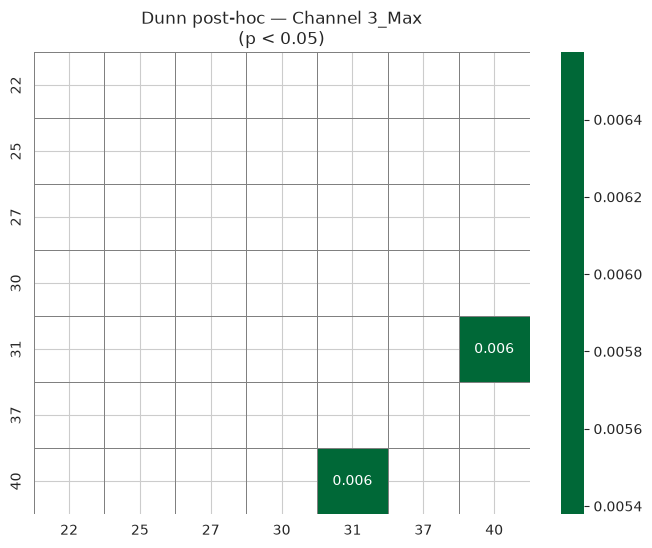

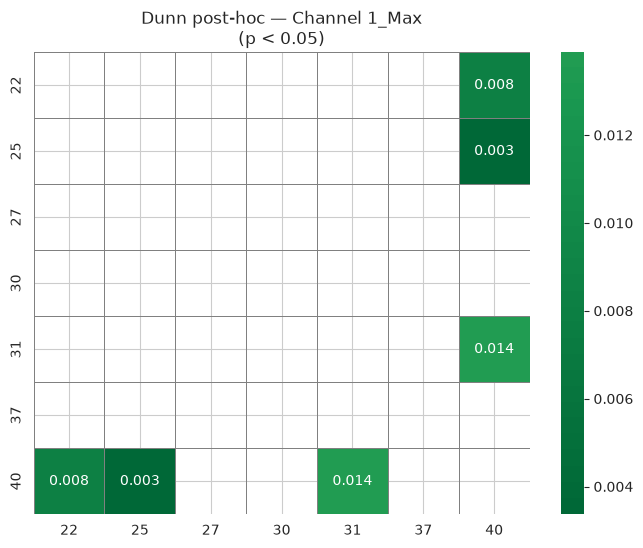

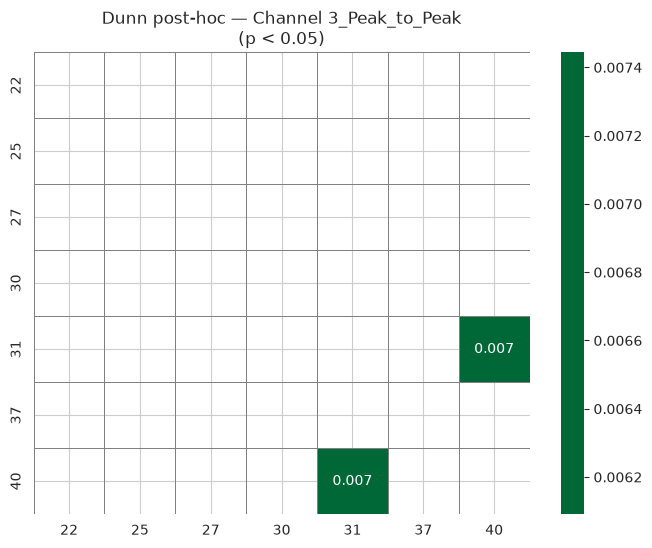

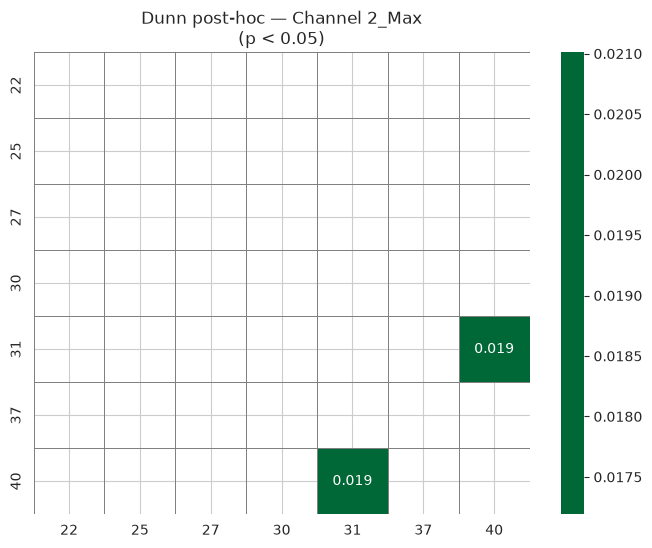

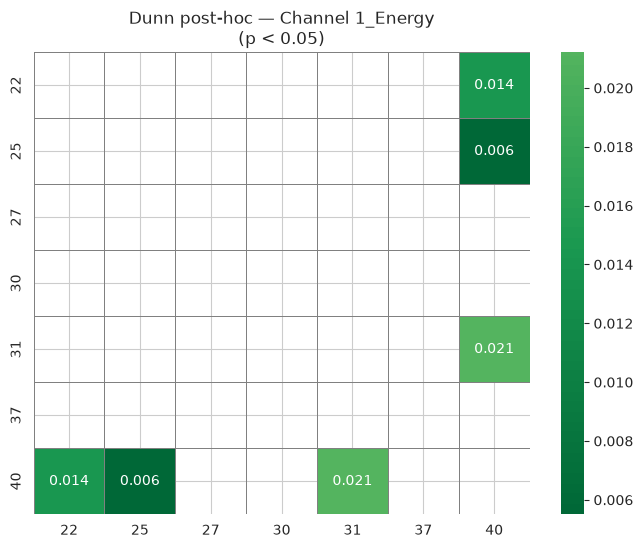

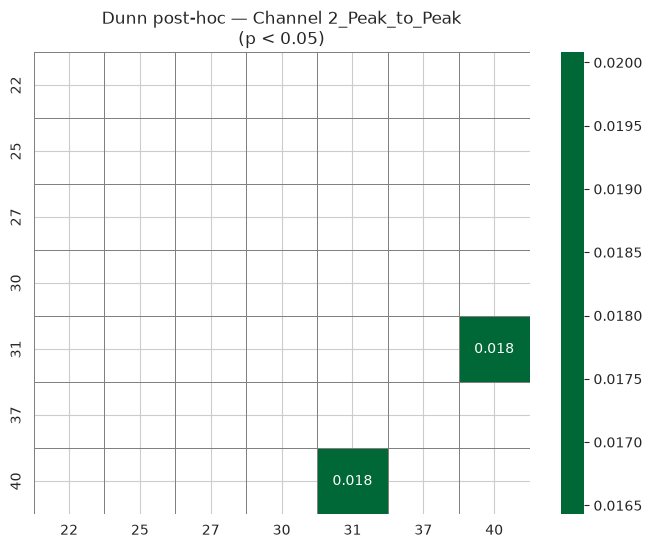

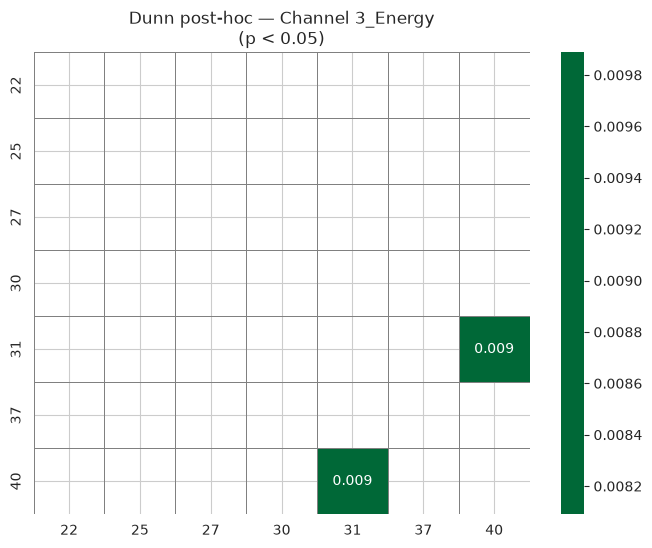

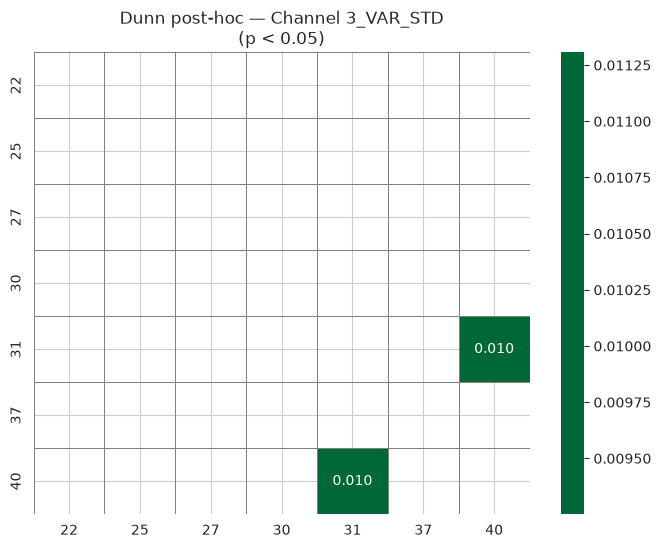

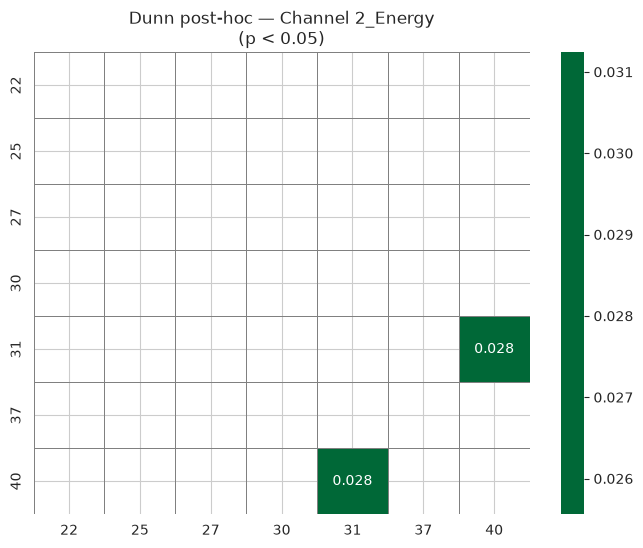

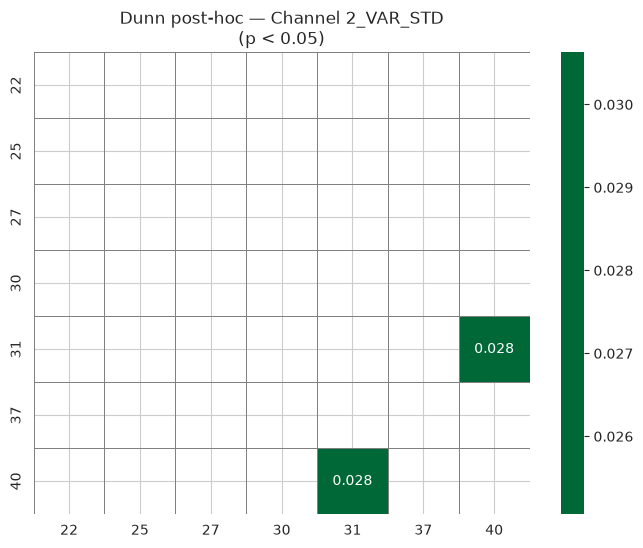

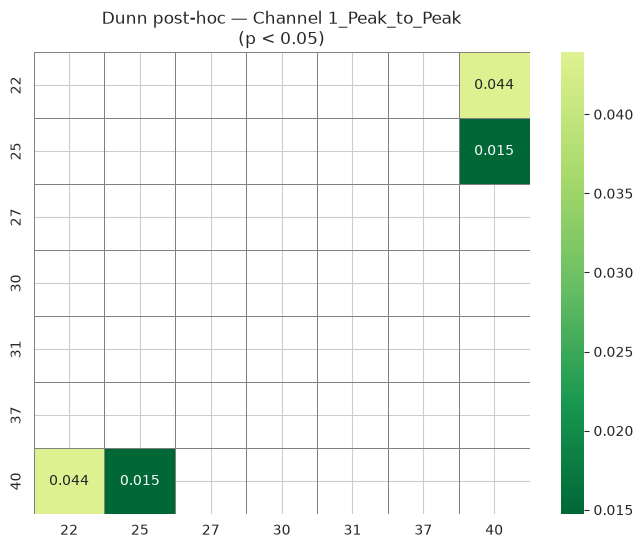

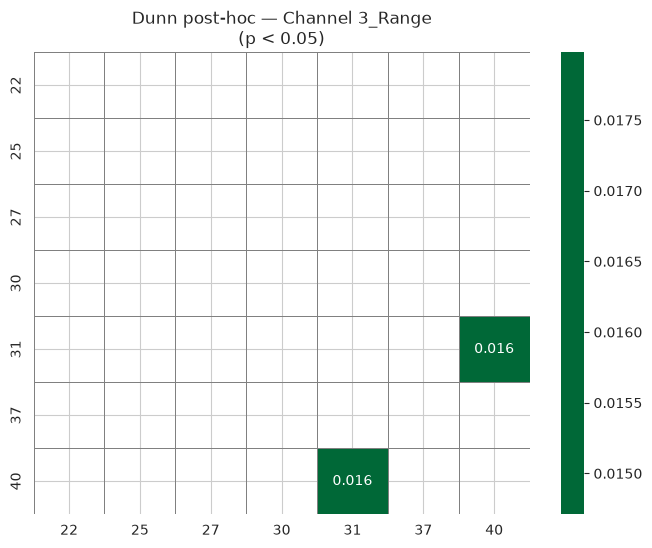

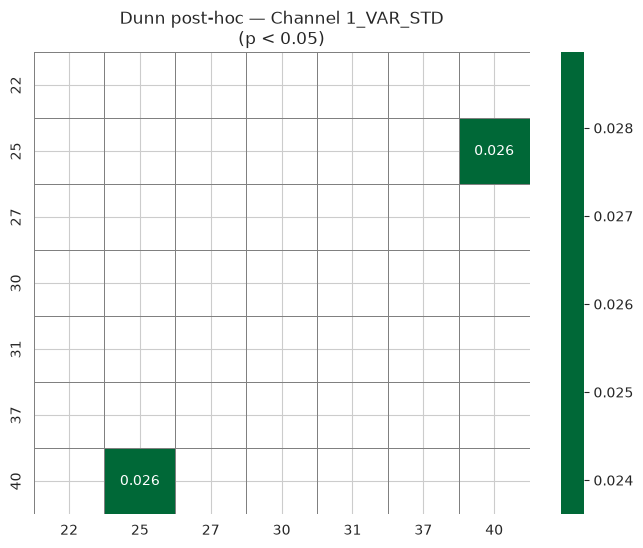

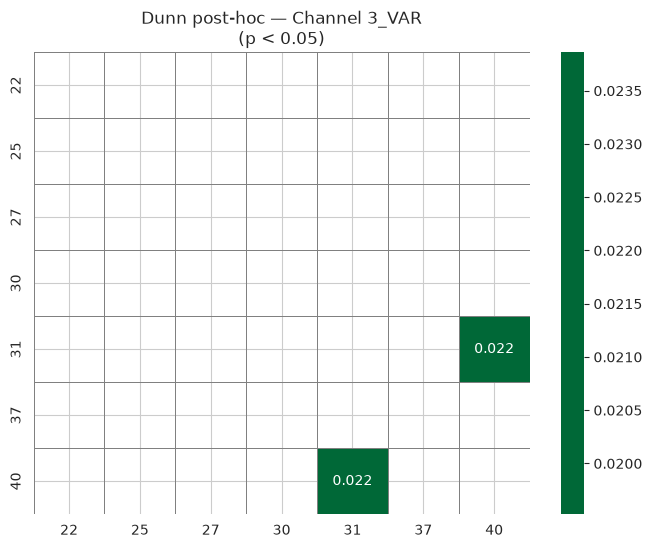

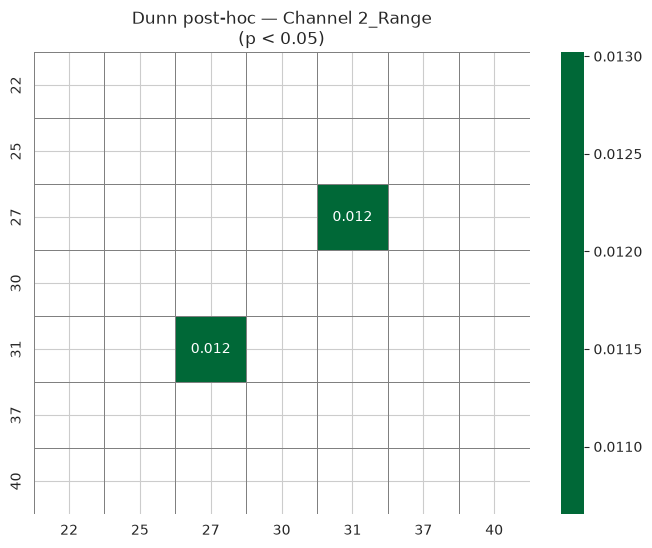

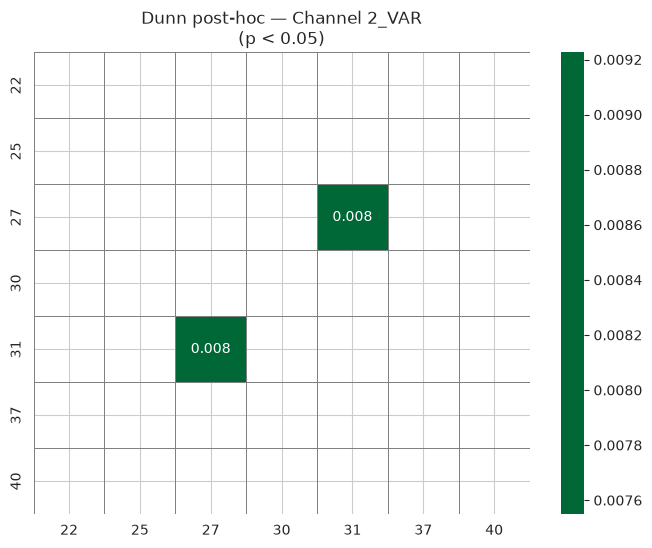

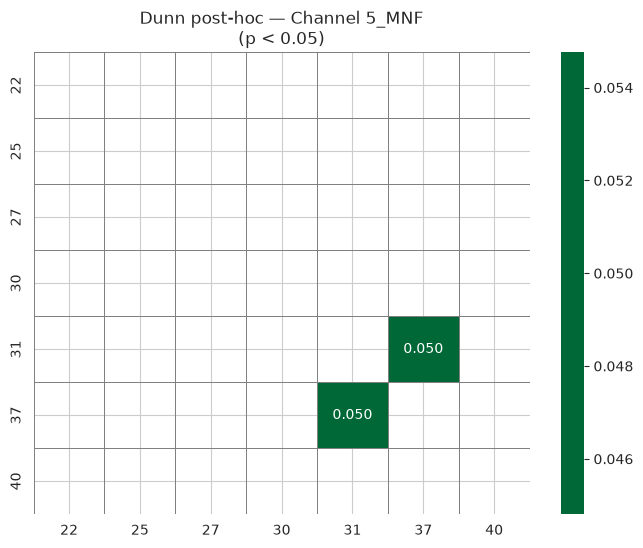

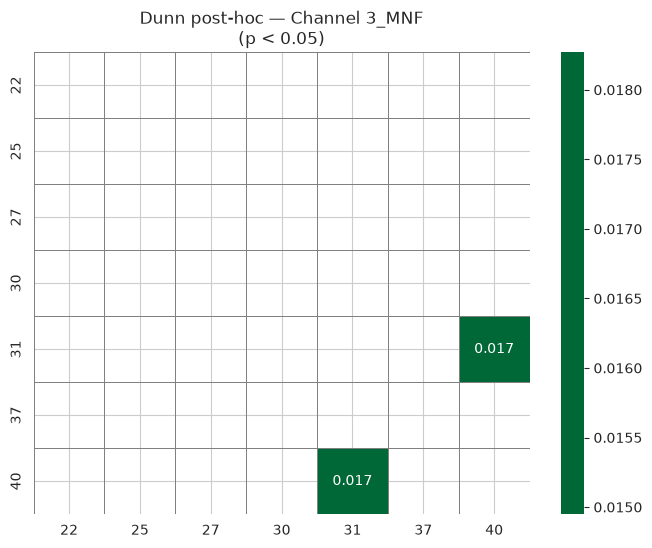

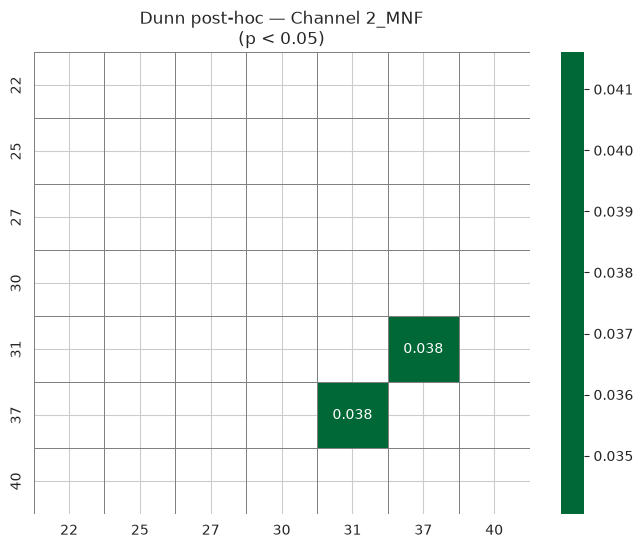

In [19]:
from scikit_posthocs import posthoc_dunn

significant = friedman_df[friedman_df['p-value'] < 0.05]['Feature'].tolist()

for feat in significant[:]:  # Top 10
    dunn = posthoc_dunn(df_avg, val_col=feat, group_col='stimulus', p_adjust='bonferroni')
    
    if (dunn < 0.05).any().any():
        mask = dunn >= 0.05
        plt.figure(figsize=(8, 6))
        sns.heatmap(dunn, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0.05,
                    mask=mask, linewidths=0.5, linecolor='gray')
        plt.title(f'Dunn post-hoc — {feat}\n(p < 0.05)')
        plt.show()

## 6. Feature importance — Random Forest

Un clasificador Random Forest predice el tipo de agarre a partir de las 64 features. La importancia de cada feature indica cuánto contribuye a la predicción.

In [20]:
X = df_avg[signal_cols].values
le = LabelEncoder()
y = le.fit_transform(df_avg['stimulus'].values)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.DataFrame({
    'Feature': signal_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f'Accuracy: {rf.score(X, y):.3f}')

Accuracy: 1.000


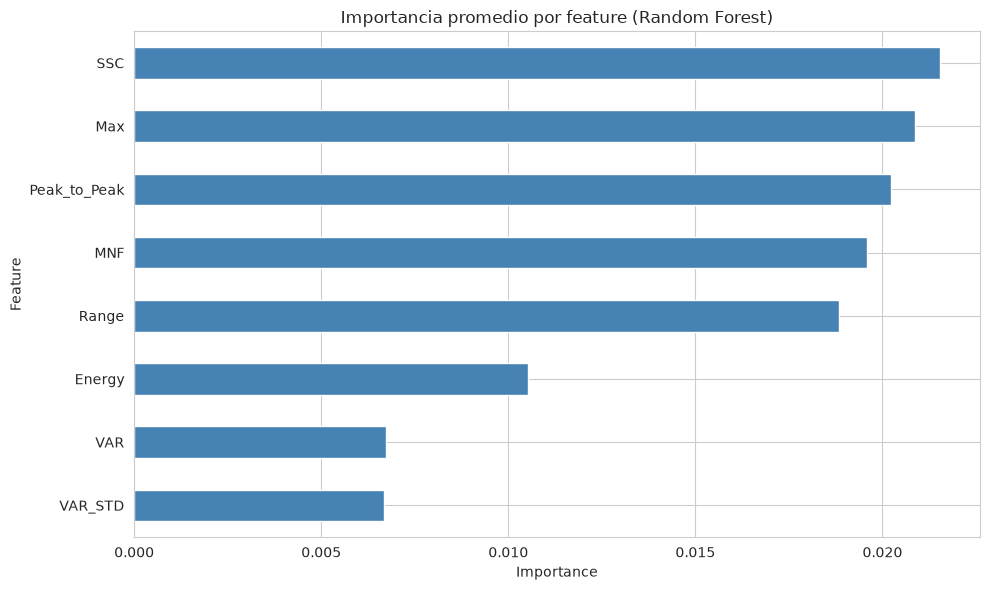

In [21]:
importances_summary = importances.copy()
importances_summary['Feature_Name'] = importances_summary['Feature'].str.extract(r'_(\w+)$')
feat_importance = importances_summary.groupby('Feature_Name')['Importance'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh', color='steelblue')
plt.title('Importancia promedio por feature (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

/tmp/ipykernel_35417/3248818229.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, y='Feature', x='Importance', palette='viridis')


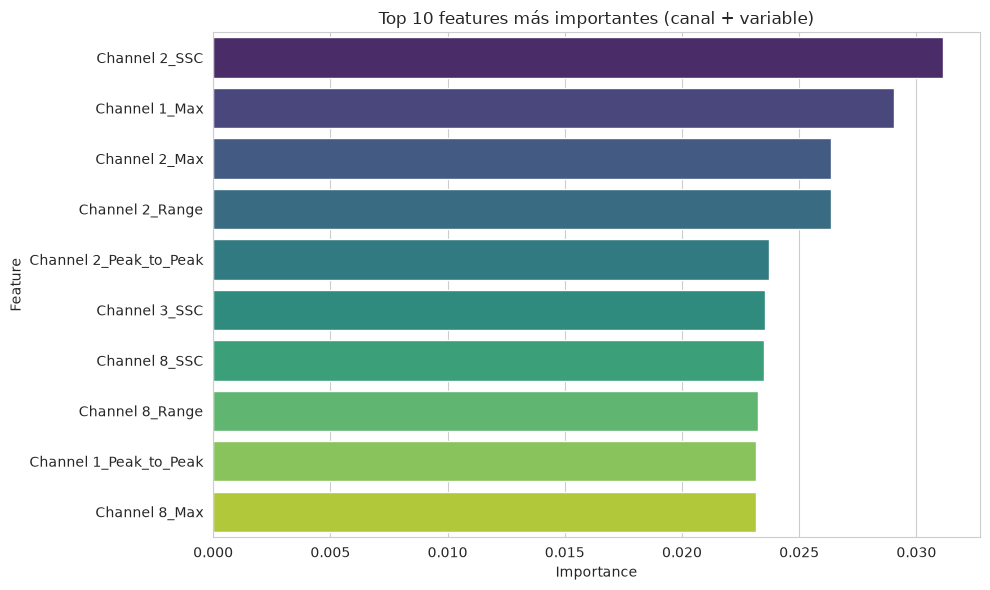

In [22]:
top_10 = importances.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, y='Feature', x='Importance', palette='viridis')
plt.title('Top 10 features más importantes (canal + variable)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Reducción dimensional — PCA y t-SNE

Visualización de los agarres en 2 dimensiones usando PCA (lineal) y t-SNE (no lineal). Cada punto es un sujeto haciendo un agarre.

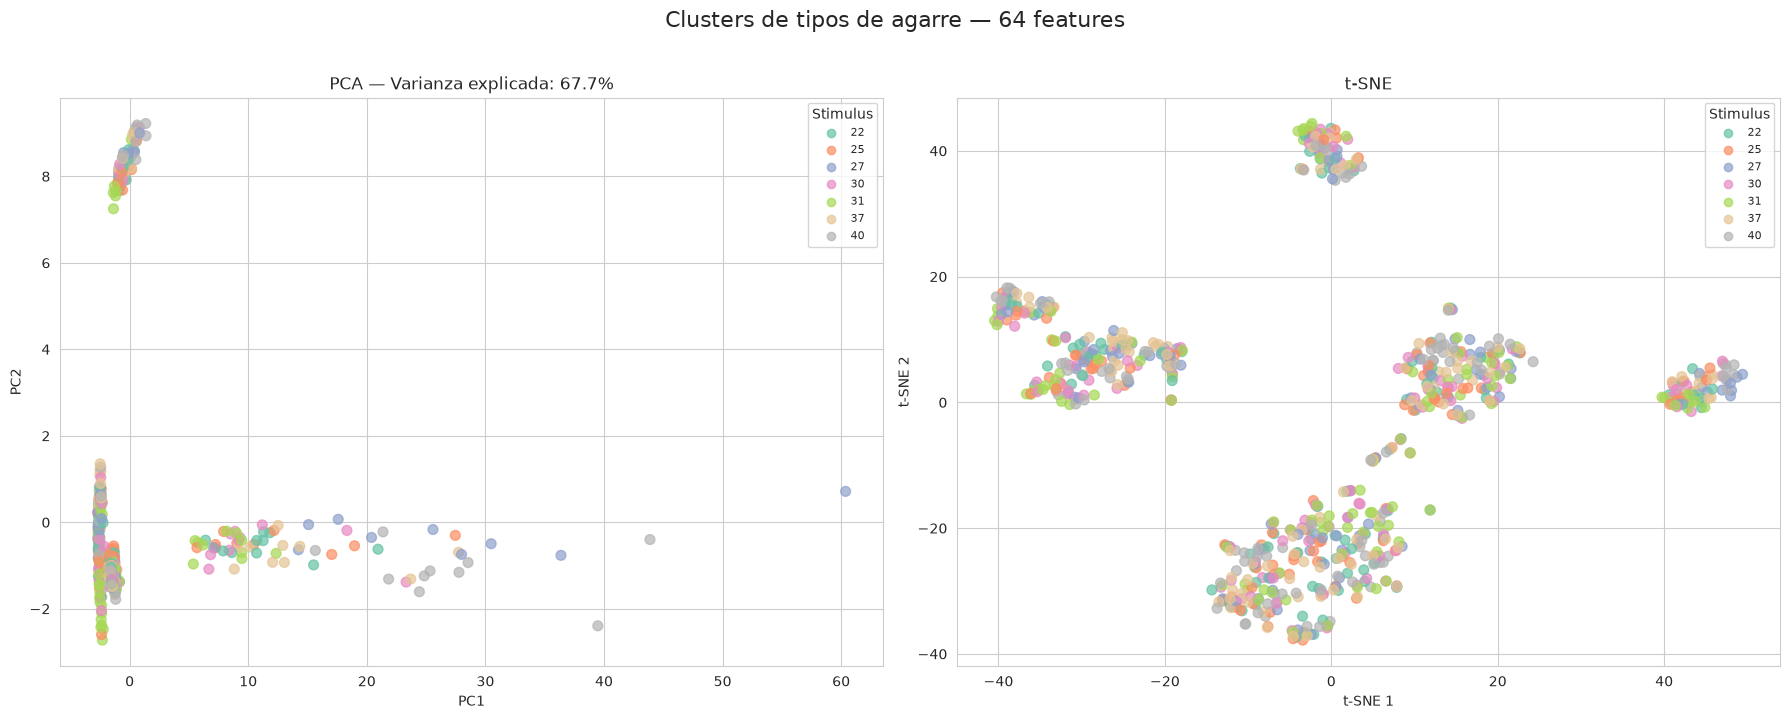

In [23]:
X = df_avg[signal_cols].values
y = df_avg['stimulus'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set2', s=50, alpha=0.7)
axes[0].set_title(f'PCA — Varianza explicada: {pca.explained_variance_ratio_.sum():.1%}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(*scatter1.legend_elements(), title='Stimulus', fontsize=8)

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='Set2', s=50, alpha=0.7)
axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(*scatter2.legend_elements(), title='Stimulus', fontsize=8)

fig.suptitle('Clusters de tipos de agarre — 64 features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. PCA Loadings — ¿Qué features contribuyen a PC1 y PC2?

Análisis de las contribuciones de cada feature a los componentes principales.

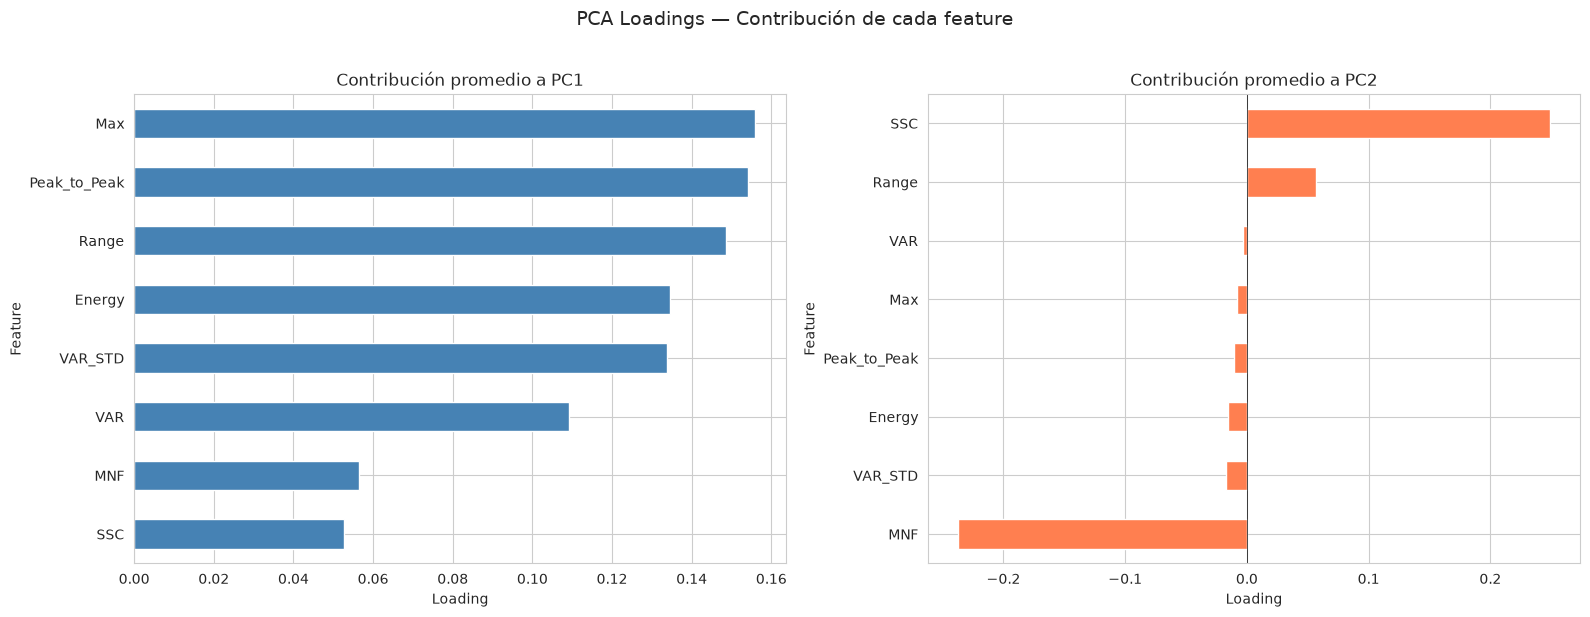

In [24]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=signal_cols,
    columns=['PC1', 'PC2']
)

# Corregir: eliminar prefijo 'Channel X_' en lugar de extraer después del último _
loadings['Feature'] = loadings.index.str.replace(r'Channel \d+_', '', regex=True)
loadings_avg = loadings.groupby('Feature')[['PC1', 'PC2']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
loadings_avg['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Contribución promedio a PC1')
axes[0].set_xlabel('Loading')
axes[0].axvline(x=0, color='black', linewidth=0.5)

loadings_avg['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Contribución promedio a PC2')
axes[1].set_xlabel('Loading')
axes[1].axvline(x=0, color='black', linewidth=0.5)

fig.suptitle('PCA Loadings — Contribución de cada feature', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Efecto del género en los agarres

Comparación de patrones EMG entre hombres y mujeres para cada tipo de agarre.

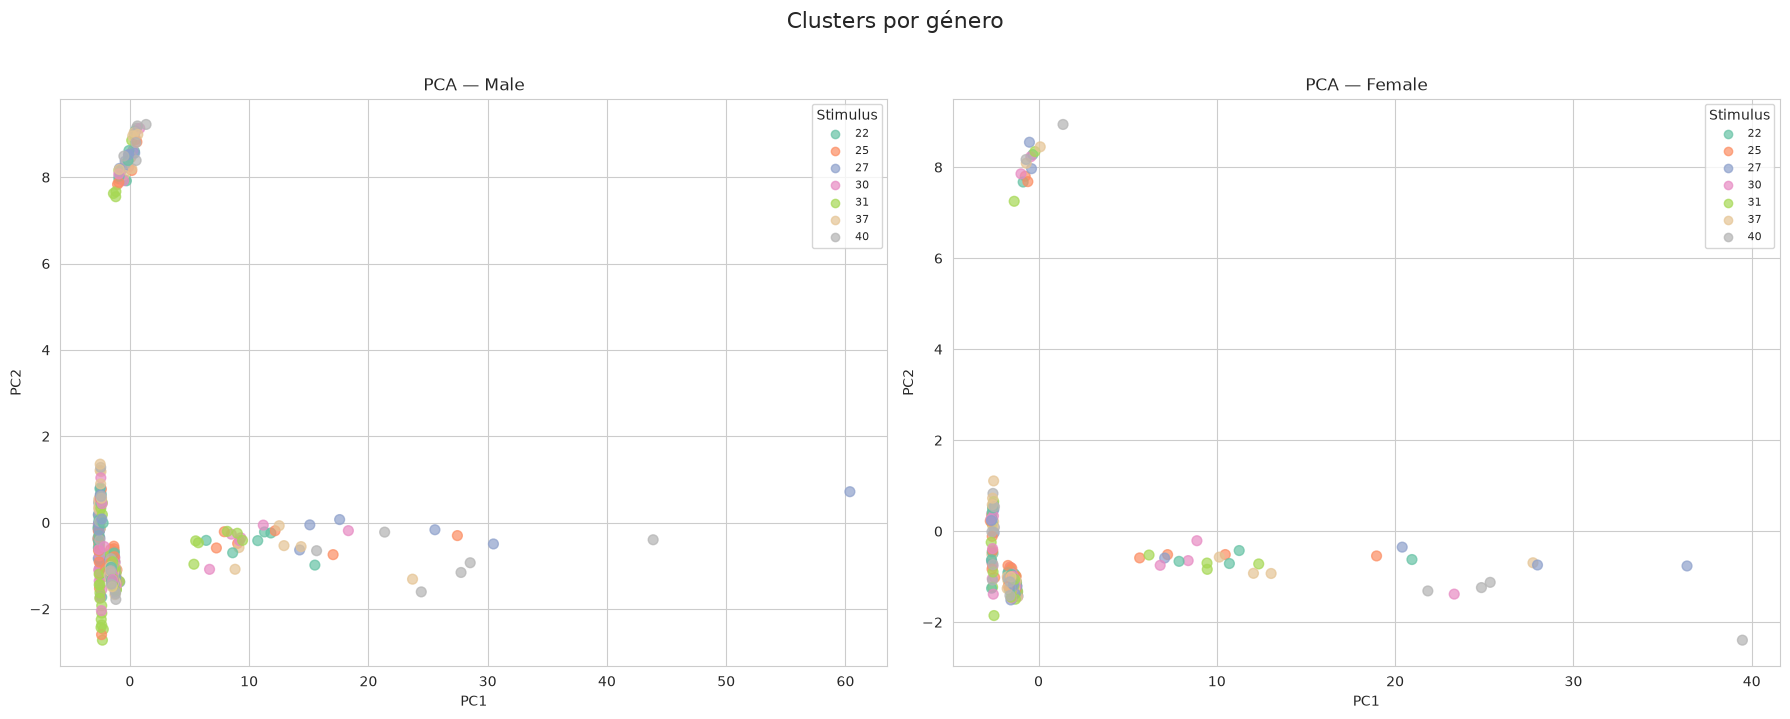

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for i, gender in enumerate(['Male', 'Female']):
    mask = df_avg['Gender'] == gender
    scatter = axes[i].scatter(X_pca[mask, 0], X_pca[mask, 1], c=y[mask], cmap='Set2', s=50, alpha=0.7)
    axes[i].set_title(f'PCA — {gender}')
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')
    axes[i].legend(*scatter.legend_elements(), title='Stimulus', fontsize=8)

fig.suptitle('Clusters por género', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 10. Validación con ventanas individuales

Verificación de que los patrones observados en el promedio también se sostienen a nivel de ventanas individuales.

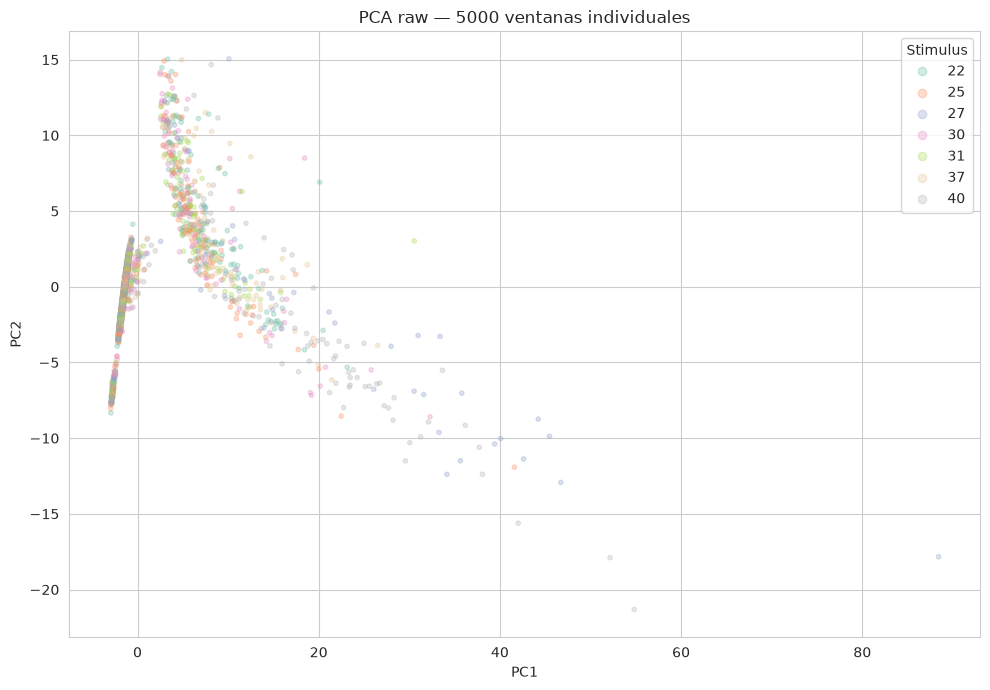

In [26]:
sample_size = min(5000, len(df_raw))
df_sample = df_raw.sample(n=sample_size, random_state=42)
X_raw = df_sample[signal_cols].values
y_raw = df_sample['stimulus'].values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

X_raw_pca = PCA(n_components=2, random_state=42).fit_transform(X_raw_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_raw_pca[:, 0], X_raw_pca[:, 1], c=y_raw, cmap='Set2', s=10, alpha=0.3)
plt.title(f'PCA raw — {sample_size} ventanas individuales')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title='Stimulus')
plt.tight_layout()
plt.show()

## 11. Comportamiento por base de datos

Análisis de las diferencias entre bases de datos (DB1, DB2, DB4, DB5, DB7) para evaluar:
1. Si las distribuciones de features son comparables entre DBs
2. Si el efecto del tipo de agarre es consistente across DBs
3. Cómo afecta la normalización por DB al análisis

/tmp/ipykernel_35417/1272636808.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_avg, x='Database', y=mean_col, ax=ax, palette='Set2')
/tmp/ipykernel_35417/1272636808.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_avg, x='Database', y=mean_col, ax=ax, palette='Set2')
/tmp/ipykernel_35417/1272636808.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_avg, x='Database', y=mean_col, ax=ax, palette='Set2')
/tmp/ipykernel_35417/1272636808.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is depre

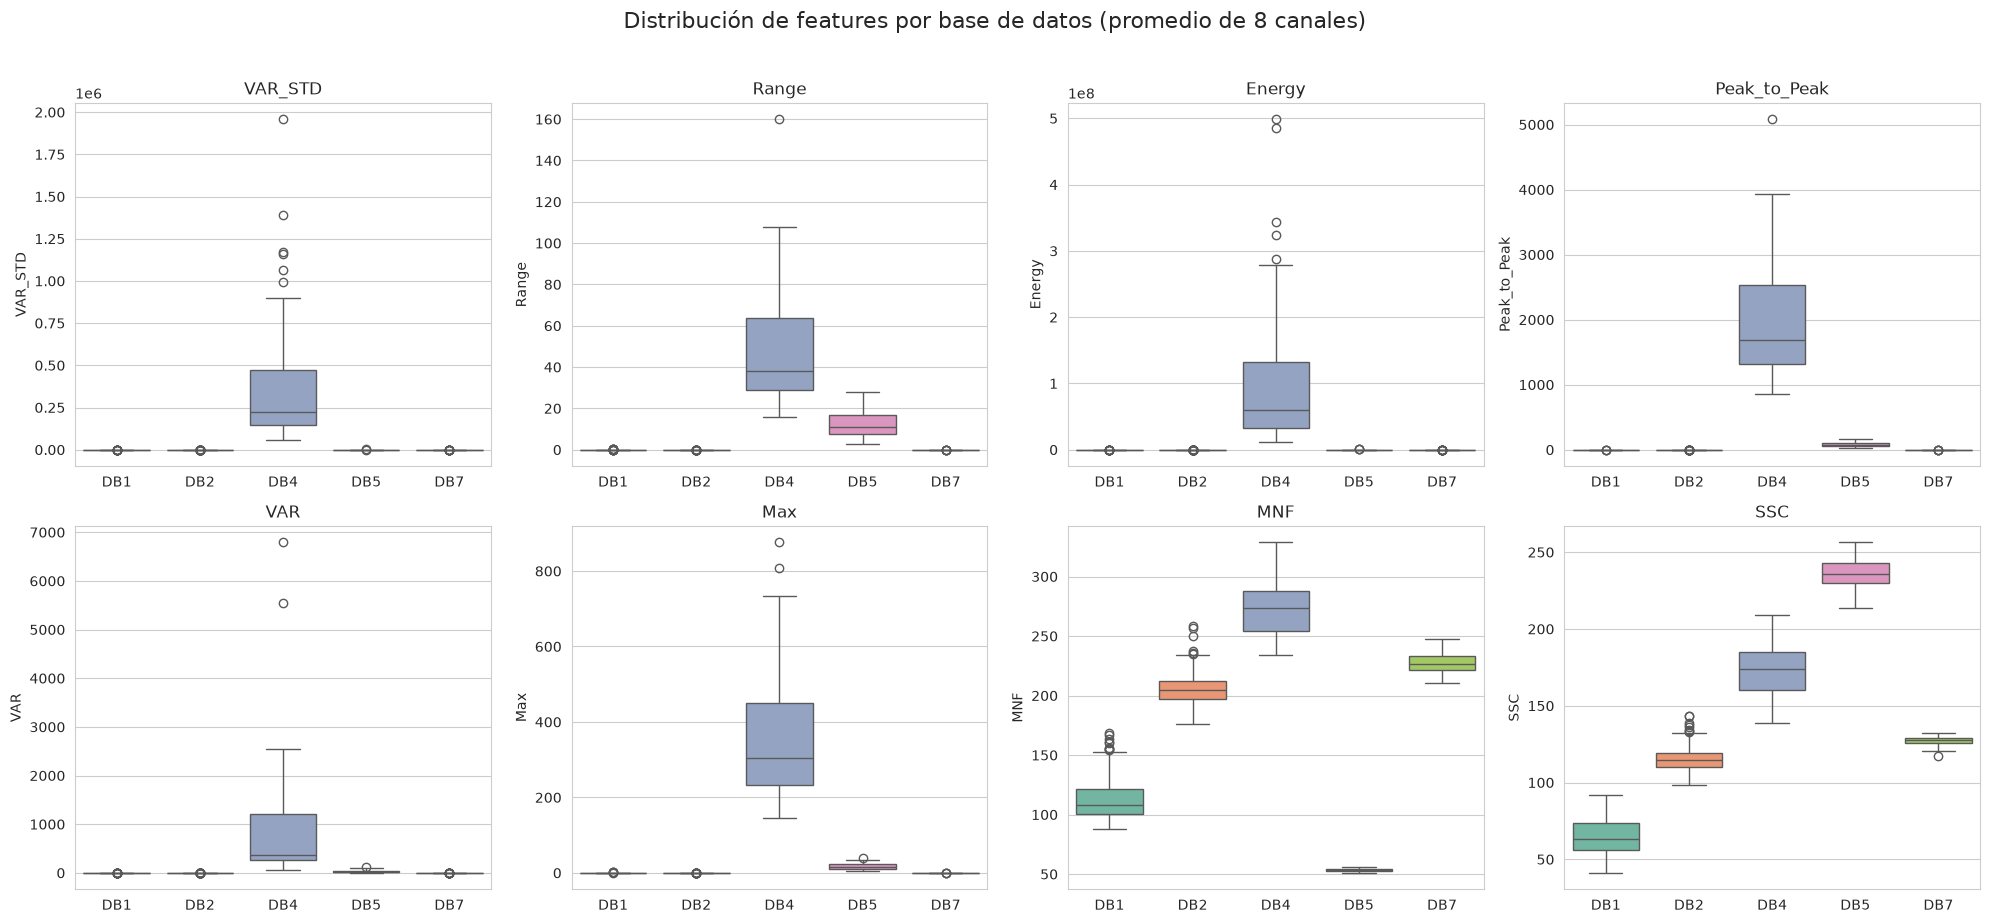

In [27]:
features = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']

# Crear columna promedio por feature (promedio de los 8 canales)
for feat in features:
    feat_cols = [f'Channel {ch}_{feat}' for ch in range(1, 9)]
    df_avg[f'{feat}_mean'] = df_avg[feat_cols].mean(axis=1)

# Plot
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Distribución de features por base de datos (promedio de 8 canales)', fontsize=16, y=1.02)

for idx, feat in enumerate(features):
    ax = axes[idx // 4, idx % 4]
    mean_col = f'{feat}_mean'
    sns.boxplot(data=df_avg, x='Database', y=mean_col, ax=ax, palette='Set2')
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel(feat)

plt.tight_layout()
plt.show()

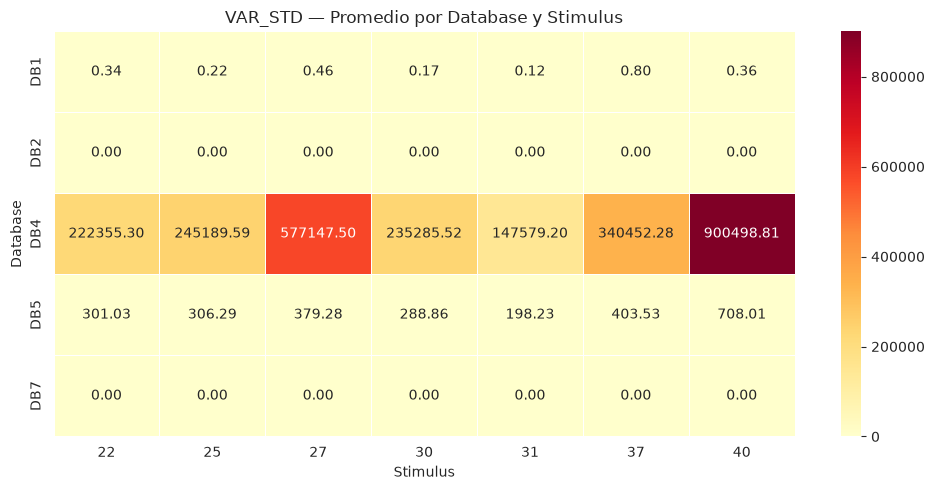

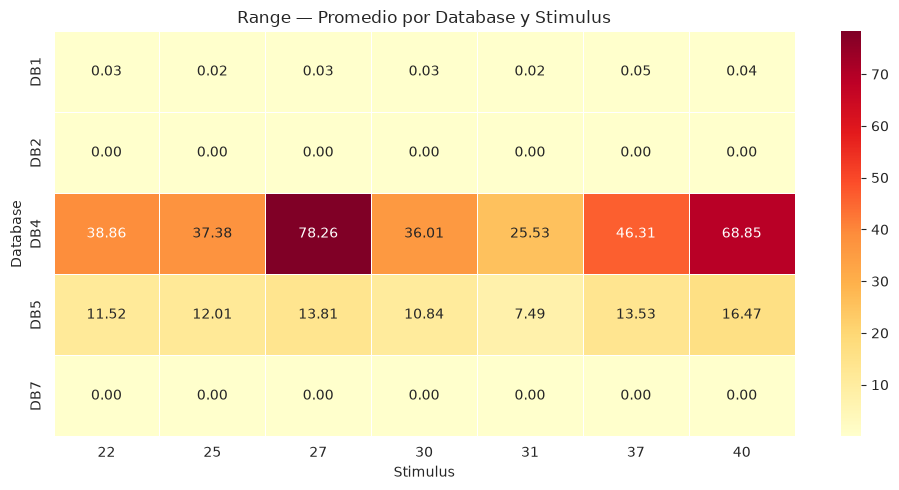

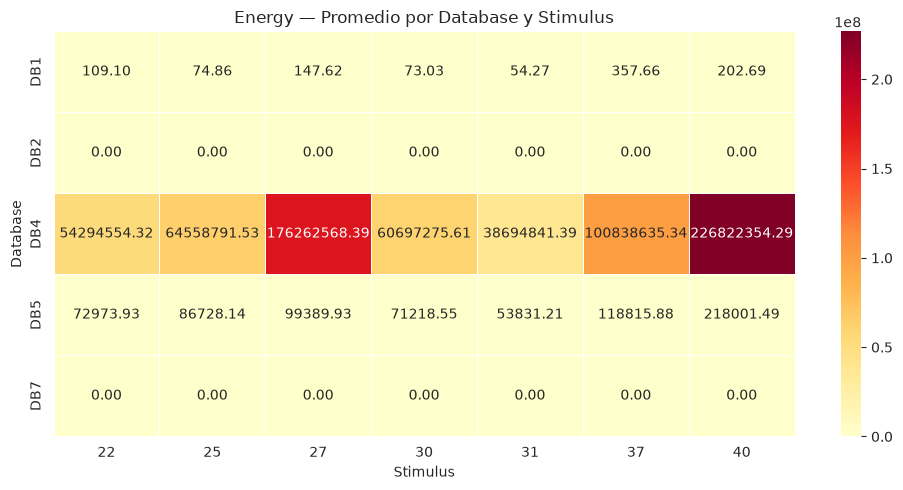

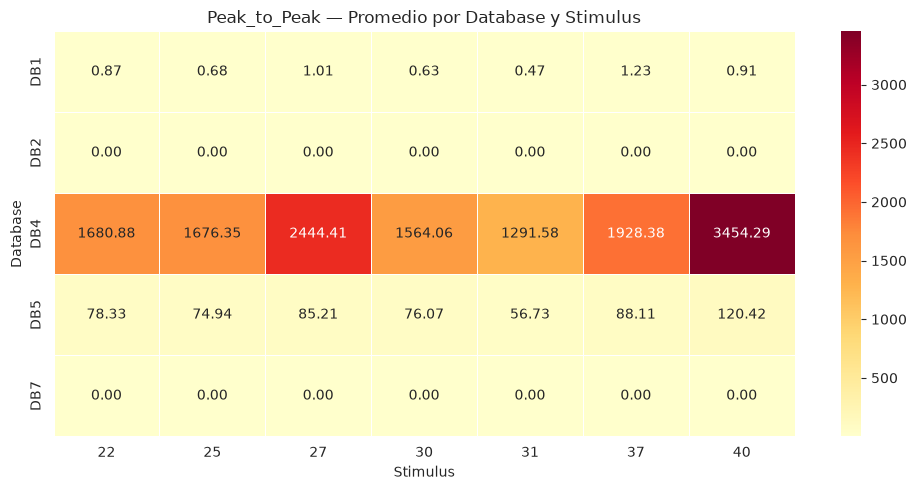

In [28]:
for feat in features[:4]:
    mean_col = f'{feat}_mean'
    pivot = df_avg.groupby(['Database', 'stimulus'])[mean_col].mean().unstack()
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title(f'{feat} — Promedio por Database y Stimulus')
    plt.xlabel('Stimulus')
    plt.ylabel('Database')
    plt.tight_layout()
    plt.show()

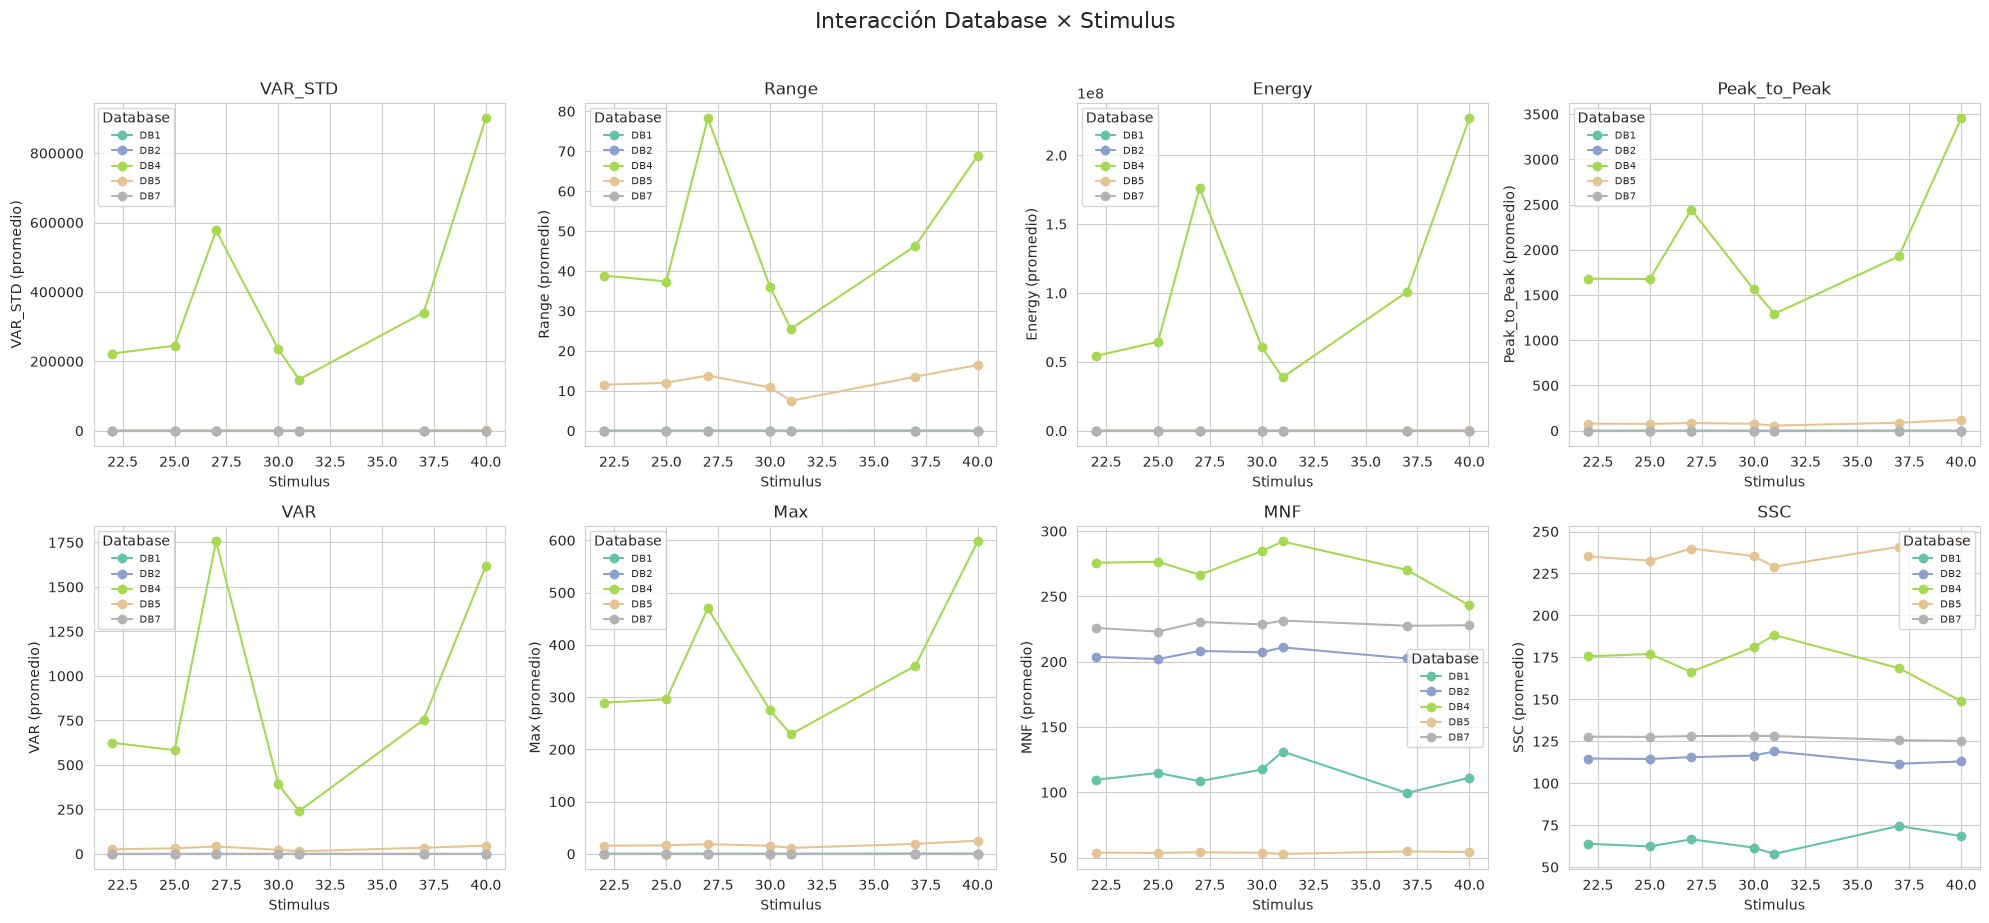

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Interacción Database × Stimulus', fontsize=16, y=1.02)

for idx, feat in enumerate(features):
    ax = axes[idx // 4, idx % 4]
    mean_col = f'{feat}_mean'
    pivot = df_avg.groupby(['Database', 'stimulus'])[mean_col].mean().unstack()
    pivot.T.plot(kind='line', marker='o', ax=ax, colormap='Set2')
    ax.set_title(feat)
    ax.set_xlabel('Stimulus')
    ax.set_ylabel(f'{feat} (promedio)')
    ax.legend(title='Database', fontsize=7)

plt.tight_layout()
plt.show()

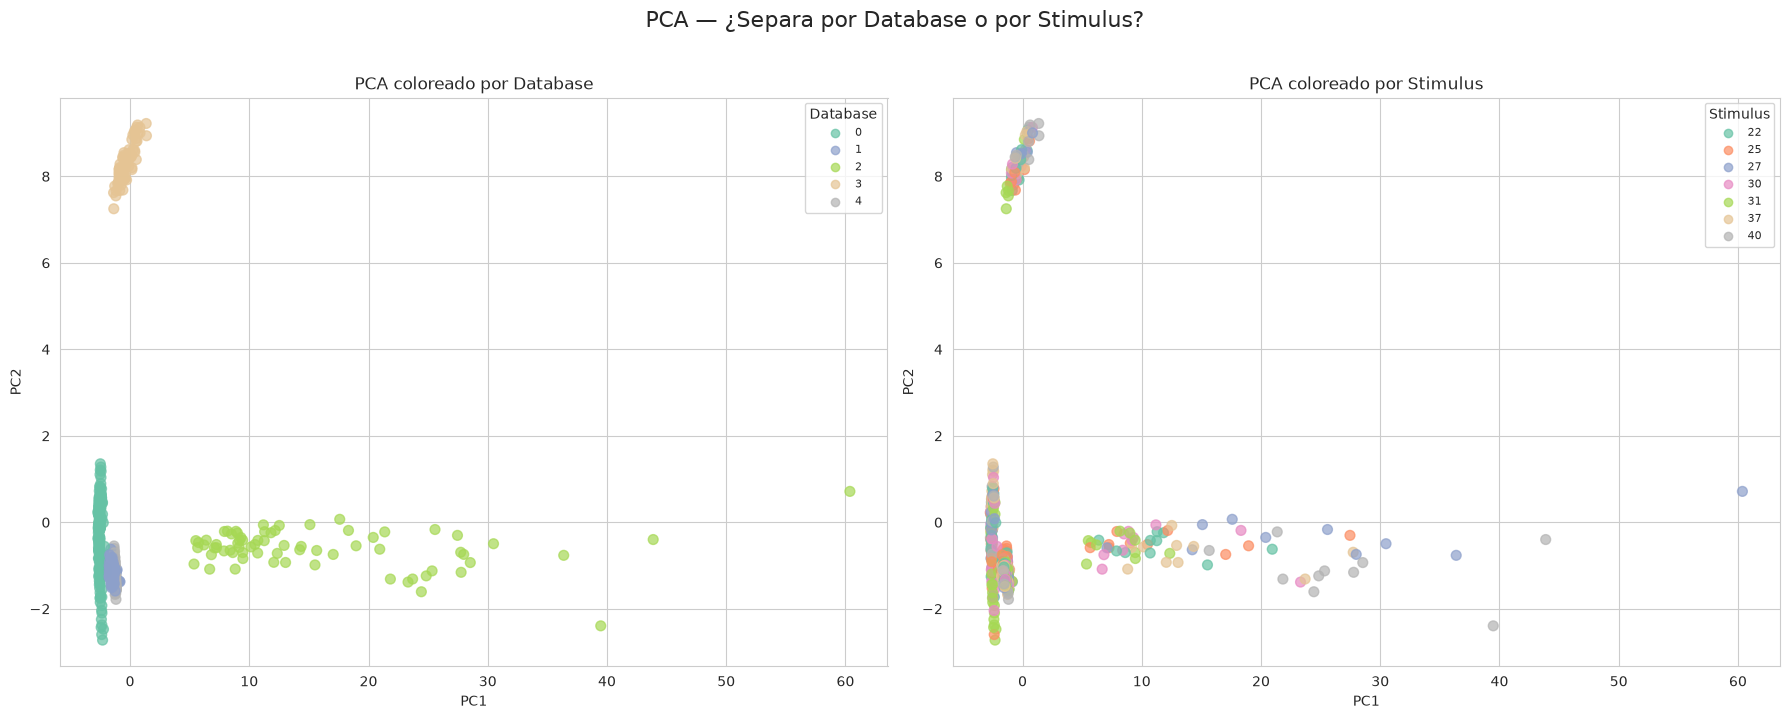

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=df_avg['Database'].astype('category').cat.codes, 
                           cmap='Set2', s=50, alpha=0.7)
axes[0].set_title('PCA coloreado por Database')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(*scatter1.legend_elements(), title='Database', fontsize=8)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=y, cmap='Set2', s=50, alpha=0.7)
axes[1].set_title('PCA coloreado por Stimulus')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(*scatter2.legend_elements(), title='Stimulus', fontsize=8)

fig.suptitle('PCA — ¿Separa por Database o por Stimulus?', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

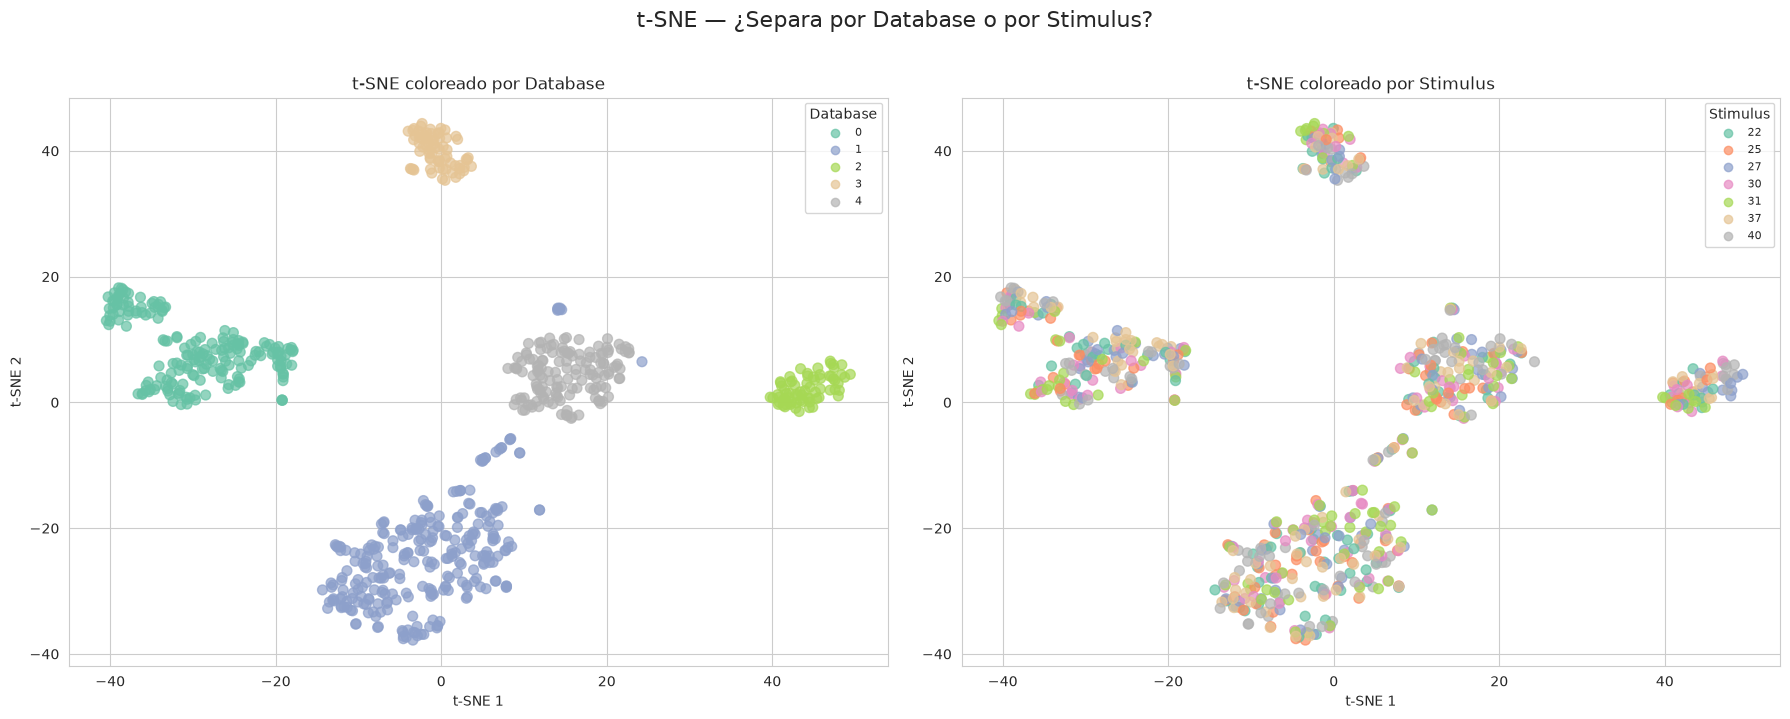

In [31]:
tsne_db = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne_db = tsne_db.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(X_tsne_db[:, 0], X_tsne_db[:, 1], 
                           c=df_avg['Database'].astype('category').cat.codes,
                           cmap='Set2', s=50, alpha=0.7)
axes[0].set_title('t-SNE coloreado por Database')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(*scatter1.legend_elements(), title='Database', fontsize=8)

scatter2 = axes[1].scatter(X_tsne_db[:, 0], X_tsne_db[:, 1], 
                           c=y, cmap='Set2', s=50, alpha=0.7)
axes[1].set_title('t-SNE coloreado por Stimulus')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(*scatter2.legend_elements(), title='Stimulus', fontsize=8)

fig.suptitle('t-SNE — ¿Separa por Database o por Stimulus?', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 12. Normalización por base de datos

Estandarización de cada feature dentro de cada database (z-score within-DB) para eliminar efectos de escala entre equipos. Esto permite comparar agarres de forma más justa entre bases de datos.

In [32]:
from scipy.stats import zscore

df_norm = df_avg.copy()
for db in df_avg['Database'].unique():
    mask = df_avg['Database'] == db
    df_norm.loc[mask, signal_cols] = zscore(df_avg.loc[mask, signal_cols])

print('Normalización completada (z-score within-DB)')
df_norm[signal_cols].describe().round(3).loc[['mean', 'std', 'min', 'max']]

Normalización completada (z-score within-DB)


,Channel 1_VAR_STD,Channel 1_Range,Channel 1_Energy,Channel 1_Peak_to_Peak,Channel 1_VAR,Channel 1_Max,Channel 1_MNF,Channel 1_SSC,Channel 2_VAR_STD,Channel 2_Range,...,Channel 7_MNF,Channel 7_SSC,Channel 8_VAR_STD,Channel 8_Range,Channel 8_Energy,Channel 8_Peak_to_Peak,Channel 8_VAR,Channel 8_Max,Channel 8_MNF,Channel 8_SSC
mean,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,...,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,...,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.041,-1.406,-0.845,-1.641,-0.904,-1.403,-3.624,-5.440,-1.195,-1.574,...,-3.344,-4.020,-1.044,-1.487,-0.824,-1.860,-0.734,-1.790,-2.962,-3.493
max,9.261,8.720,11.956,7.385,13.419,7.860,3.197,4.377,16.691,16.307,...,6.262,6.376,11.701,8.514,9.762,7.135,9.682,7.309,6.053,5.633


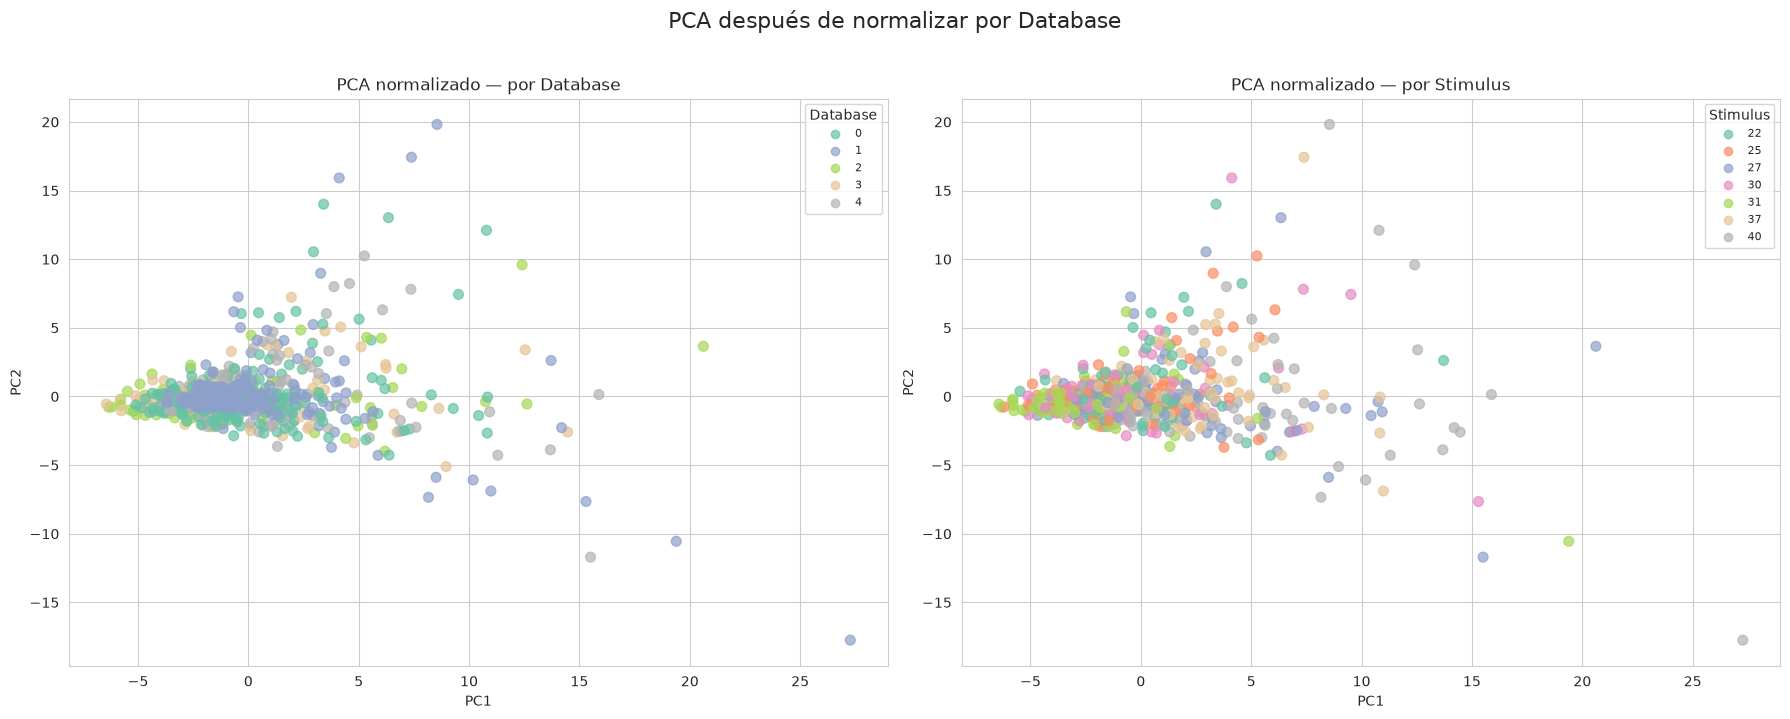

In [33]:
X_norm = df_norm[signal_cols].values
y_norm = df_norm['stimulus'].values
X_norm_scaled = StandardScaler().fit_transform(X_norm)
X_norm_pca = PCA(n_components=2, random_state=42).fit_transform(X_norm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(X_norm_pca[:, 0], X_norm_pca[:, 1], 
                           c=df_norm['Database'].astype('category').cat.codes,
                           cmap='Set2', s=50, alpha=0.7)
axes[0].set_title('PCA normalizado — por Database')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(*scatter1.legend_elements(), title='Database', fontsize=8)

scatter2 = axes[1].scatter(X_norm_pca[:, 0], X_norm_pca[:, 1], 
                           c=y_norm, cmap='Set2', s=50, alpha=0.7)
axes[1].set_title('PCA normalizado — por Stimulus')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(*scatter2.legend_elements(), title='Stimulus', fontsize=8)

fig.suptitle('PCA después de normalizar por Database', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

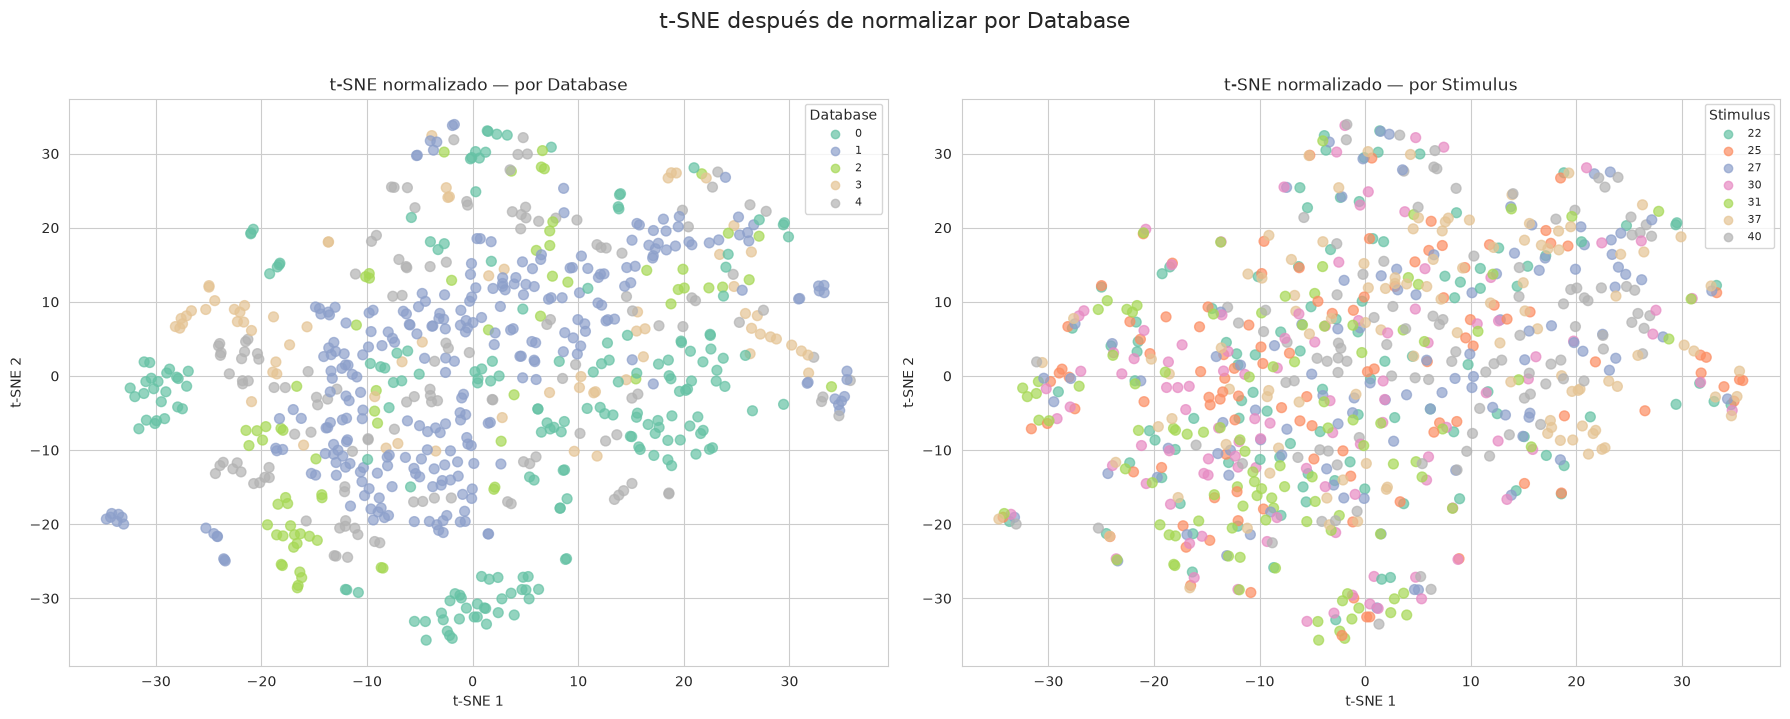

In [34]:
tsne_norm = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne_norm = tsne_norm.fit_transform(X_norm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(X_tsne_norm[:, 0], X_tsne_norm[:, 1], 
                           c=df_norm['Database'].astype('category').cat.codes,
                           cmap='Set2', s=50, alpha=0.7)
axes[0].set_title('t-SNE normalizado — por Database')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(*scatter1.legend_elements(), title='Database', fontsize=8)

scatter2 = axes[1].scatter(X_tsne_norm[:, 0], X_tsne_norm[:, 1], 
                           c=y_norm, cmap='Set2', s=50, alpha=0.7)
axes[1].set_title('t-SNE normalizado — por Stimulus')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(*scatter2.legend_elements(), title='Stimulus', fontsize=8)

fig.suptitle('t-SNE después de normalizar por Database', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()